Setup environment and load the base PyPSA-Earth network for a specified country.


In [1]:
# --- Core imports
import os
import sys
import copy
import logging
import warnings
from os.path import join
from pathlib import Path

# --- Numerical / data
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

# --- Power systems / geospatial
import pypsa
import atlite
from shapely.geometry import Point, box
from shapely.ops import unary_union
import shapely
import numpy as np
from scipy.spatial import cKDTree as KDTree

# Optional plotting (only used in helper plot function)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Optional: powerplantmatching (picks up config but we keep local CSV as source of truth)
try:
    import powerplantmatching as pm
    HAVE_PPM = True
except Exception:
    HAVE_PPM = False

# --- Silence noisy warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)
warnings.filterwarnings('ignore')


# --- Logging
parent_dir = Path(os.getcwd()).parents[0]          # project/
LOG_FILE = join(parent_dir, "logs.log")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE, encoding="utf-8"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)

# --- Project paths helper
sys.path.append(str(parent_dir))
from src.paths import all_dirs  # must exist in your repo
dirs = all_dirs()
from src.scenario_reg import SCENARIOS

# --- Add PyPSA-Earth scripts to PATH (assumes repo layout: <project>/../pypsa-earth/scripts)
scripts_path = os.path.join(parent_dir.parents[0], "pypsa-earth", "scripts")
assert os.path.isdir(scripts_path), f"Path not found: {scripts_path}"
sys.path.append(scripts_path)

scenario= SCENARIOS["CAL_2018"]


In [2]:
# 1) Load Networks
def load_network(scenario):
    network_name= scenario.network.name

    network_dir = dirs["data/processed/networks"]
    network_file = join(network_dir, network_name)

    try:
        network = pypsa.Network(network_file)
        logger.info(f"✓ loaded {network_name}.nc")
    except Exception as e:
        logger.warning(f"⚠ failed to load {network_name}.nc: {e}")

    return network

network = load_network(scenario)

2025-11-20 13:04:40: Imported network network_2018.nc has buses, lines, transformers
2025-11-20 13:04:40: ✓ loaded c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\data\processed\networks\network_2018.nc.nc


In [3]:
#1.a) Prune Network to work only at 137kV level

def prune_network_min_voltage(n, v_threshold_kv=137.0):
    """
    Keep only buses with v_nom >= v_threshold_kv and remove any components
    (transformers, lines, links, loads, generators, stores, storage_units, shunts)
    that reference removed buses.
    """
    import numpy as np
    n = n.copy()

    # 1) Decide which buses to keep
    buses_orig = n.buses.index.astype(str)
    keep_buses = n.buses.index[n.buses["v_nom"] >= float(v_threshold_kv)].astype(str)
    keep_set   = set(keep_buses)
    drop_set   = set(buses_orig) - keep_set

    print(f"Keeping {len(keep_buses)}/{len(buses_orig)} buses (v_nom >= {v_threshold_kv} kV).")
    if drop_set:
        print(f"Dropping {len(drop_set)} buses due to voltage threshold.")

    # helper to drop rows by bus column name if bus not in keep_set
    def _drop_by_bus(df, bus_col):
        if df.empty or bus_col not in df.columns:
            return df.index[:0]
        mask = ~df[bus_col].astype(str).isin(keep_set)
        return df.index[mask]

    # 2) Collect components to drop because they reference removed buses
    to_drop = {
        "Load":          _drop_by_bus(n.loads, "bus"),
        "Generator":     _drop_by_bus(n.generators, "bus"),
        "Store":         _drop_by_bus(getattr(n, "stores"), "bus") if hasattr(n, "stores") else [],
        "StorageUnit":   _drop_by_bus(n.storage_units, "bus") if hasattr(n, "storage_units") else [],
        "ShuntImpedance": _drop_by_bus(getattr(n, "shunt_impedances"), "bus") if hasattr(n, "shunt_impedances") else [],
        "Line":          n.lines.index[
                            ~n.lines["bus0"].astype(str).isin(keep_set) |
                            ~n.lines["bus1"].astype(str).isin(keep_set)
                        ],
        "Transformer":   n.transformers.index[
                            ~n.transformers["bus0"].astype(str).isin(keep_set) |
                            ~n.transformers["bus1"].astype(str).isin(keep_set)
                        ],
        "Link":          n.links.index[
                            ~n.links["bus0"].astype(str).isin(keep_set) |
                            ~n.links["bus1"].astype(str).isin(keep_set)
                        ] if len(n.links) else []
    }

    # 3) Remove them from the network using PyPSA's API
    for comp, idx in to_drop.items():
        idx = list(idx)
        if not idx:
            continue
        for name in idx:
            try:
                n.remove(comp, name)
            except Exception as e:
                # be robust if component table missing etc.
                pass
        print(f"Removed {len(idx):4d} {comp}(s) referencing dropped buses.")

    # 4) Finally, restrict the buses table itself to the kept set
    n.buses = n.buses.loc[keep_buses]

    # Optional: clean orphaned carriers/sub-networks etc. if needed

    return n

# ---- use it ----
network = prune_network_min_voltage(network, v_threshold_kv=137)
                                    #137.0)



Keeping 111/296 buses (v_nom >= 137 kV).
Dropping 185 buses due to voltage threshold.
Removed  141 Line(s) referencing dropped buses.
Removed   43 Transformer(s) referencing dropped buses.


In [4]:
def total_energy_demand(scenario) -> float:
    # first get the whole year demand of the loaded profile

    config = scenario.demand
    year = scenario.year
    demand_path = config.scaling_csv
    if not os.path.isfile(demand_path):
        logger.warning("Demand CSV %s not found; using factor=1.0", demand_path)
        return 1.0
    df = pd.read_csv(demand_path, index_col= "year")
    if year not in df.index:
        raise ValueError(
            f"Year '{config.year_column}' missing in  file {demand_path}"
        )
    prognosis_type = scenario.demand.family + "_"+ scenario.demand.projection
   
    demand = df.loc[year,prognosis_type]
    return demand




In [5]:
# 2) Loads: add p_set time series
# 2) Loads: add p_set time series with nearest-bus remapping for unknown buses
def read_and_scale_loads(scenario):
    path_loads = scenario.demand.profile_template_name
    logger.info(f"Loading load profile: {path_loads}")
    load_profile = pd.read_csv(path_loads, index_col=0, parse_dates=True)
    total_reference_energy = load_profile.sum().sum()*1e-6 #GW
    total_target_year_energy = total_energy_demand(scenario)
    scaling_factor = total_target_year_energy/total_reference_energy
    load_profile = load_profile*scaling_factor
    print(total_reference_energy)
    print(total_target_year_energy)
    logger.info(f"Total reference energy: {total_reference_energy:.2f}")
    logger.info(f"Total target-year energy: {total_target_year_energy:.2f}")
    logger.info(f"Scaled all load profile values by factor {scaling_factor:.2f}")
    return load_profile
    
load_profile = read_and_scale_loads(scenario)    


2025-11-20 13:04:40: Loading load profile: c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\data\raw\demand\demand_profiles_EC.csv
33.40563868788897
23.0
2025-11-20 13:04:41: Total reference energy: 33.41
2025-11-20 13:04:41: Total target-year energy: 23.00
2025-11-20 13:04:41: Scaled all load profile values by factor 0.69


In [6]:
import os
import numpy as np
from os.path import join
from scipy.spatial import cKDTree as KDTree
import pypsa

# assumes: dirs, logger are defined globally


def ensure_string_load_columns(load_profile):
    """Ensure load_profile columns are strings and return (profile, columns_list)."""
    load_profile = load_profile.copy()
    load_cols = [str(c) for c in load_profile.columns]
    load_profile.columns = load_cols
    return load_profile, load_cols


def get_existing_buses(network):
    """Return (buses_now, existing_buses_set). Index is cast to str."""
    buses_now = network.buses.copy()
    buses_now.index = buses_now.index.astype(str)
    existing_buses = set(buses_now.index)
    return buses_now, existing_buses


def log_missing_buses(load_cols, existing_buses):
    """Log whether there are missing buses in the current network."""
    missing = [c for c in load_cols if c not in existing_buses]
    if missing:
        logger.warning(
            f"{len(missing)} load buses not found; reassigning to nearest existing bus."
        )
    else:
        logger.info("All load buses found in current network.")


def build_kdtree_for_buses(buses_now):
    """
    Build KDTree for current network buses.

    Returns (coords_now, kdt_now, use_lonlat).
    """
    use_lonlat = {"lon", "lat"}.issubset(buses_now.columns)
    if use_lonlat:
        coords_now = buses_now.loc[:, ["lon", "lat"]].to_numpy(dtype=float)
    else:
        coords_now = buses_now.loc[:, ["x", "y"]].to_numpy(dtype=float)

    kdt_now = KDTree(coords_now)
    return coords_now, kdt_now, use_lonlat


def load_fallback_networks():
    """
    Load fallback networks from disk.

    Returns a dict {name: pypsa.Network}.
    """
    network_dir_fb = dirs["data/processed/networks"]
    network_files_fb = ["network_original"]
    fallback_networks = {}

    for nf in network_files_fb:
        f = join(network_dir_fb, f"{nf}.nc")
        if os.path.isfile(f):
            fallback_networks[nf] = pypsa.Network(f)

    return fallback_networks


def find_bus_coords_in_fallbacks(bus_name, fallback_networks):
    """
    Try to get coordinates for a missing bus from any fallback network.

    Returns:
        ("lonlat", lon, lat) or ("xy", x, y) or None.
    """
    for nf, net_fb in fallback_networks.items():
        try:
            df = net_fb.buses.copy()
            df.index = df.index.astype(str)
            if bus_name in df.index:
                if {"lon", "lat"}.issubset(df.columns):
                    return (
                        "lonlat",
                        float(df.loc[bus_name, "lon"]),
                        float(df.loc[bus_name, "lat"]),
                    )
                elif {"x", "y"}.issubset(df.columns):
                    return (
                        "xy",
                        float(df.loc[bus_name, "x"]),
                        float(df.loc[bus_name, "y"]),
                    )
        except Exception:
            # ignore failures on individual fallback networks
            pass

    return None


def build_bus_assignments(
    load_cols, existing_buses, buses_now, coords_now, kdt_now, use_lonlat, fallback_networks
):
    """
    Build bus assignment list for each load column and collect a remap report.

    Returns (bus_assignments, remap_report).
    """
    bus_assignments = []
    remap_report = []

    # precompute centroid for “no info” cases
    centroid = np.nanmedian(coords_now, axis=0)[None, :]

    for c in load_cols:
        if c in existing_buses:
            bus_assignments.append(c)  # unchanged
            continue

        # Try to recover coordinates for this bus label from other networks
        info = find_bus_coords_in_fallbacks(c, fallback_networks)

        if info is not None:
            kind, bx, by = info

            # Query KDTree (always built for current network in the coordinate type we have)
            if use_lonlat and kind == "lonlat":
                q = np.array([[bx, by]])
            elif (not use_lonlat) and kind == "xy":
                q = np.array([[bx, by]])
            else:
                # Coordinate kind mismatch; cannot reliably transform → use crude nearest
                # by lon/lat if both exist, else by x/y. If mismatch, use network centroid.
                remap_report.append((c, None, None, "coord_kind_mismatch"))
                q = centroid

            idx = int(kdt_now.query(q)[1][0])
            nearest_bus = buses_now.index[idx]
            bus_assignments.append(nearest_bus)
            remap_report.append((c, bx, by, f"mapped_to:{nearest_bus}"))

        else:
            # No coordinates found anywhere → attach to globally nearest by network centroid
            idx = int(kdt_now.query(centroid)[1][0])
            nearest_bus = buses_now.index[idx]
            bus_assignments.append(nearest_bus)
            remap_report.append(
                (c, None, None, f"mapped_to:{nearest_bus};reason:no_coords")
            )

    return bus_assignments, remap_report


def log_remap_report(remap_report):
    """Log detailed remapping information."""
    if not remap_report:
        return

    logger.info("Load bus remapping performed (missing → nearest existing):")
    for r in remap_report:
        logger.info(f"  load '{r[0]}' → {r[3]} (src_coords: {r[1]}, {r[2]})")


def log_peak_load(network):
    """Compute and log peak load in GW from loads_t.p_set."""
    peak_load = round(network.loads_t.p_set.T.sum().max() / 1000, 1)
    logger.info(f"Peak load in p_set time series: {peak_load} GW")


def add_profiles_to_nearest_bus(load_profile, network):
    """
    Main wrapper: keep behaviour identical, but orchestrate smaller helpers.
    """
    try:
        # --- Ensure column names are strings
        load_profile, load_cols = ensure_string_load_columns(load_profile)

        # --- Existing buses in the active network
        buses_now, existing_buses = get_existing_buses(network)

        # --- Find missing bus labels and log
        log_missing_buses(load_cols, existing_buses)

        # --- Build KDTree on current network buses
        coords_now, kdt_now, use_lonlat = build_kdtree_for_buses(buses_now)

        # --- Load fallback networks
        fallback_networks = load_fallback_networks()

        # --- Build a bus assignment vector aligned with load columns
        bus_assignments, remap_report = build_bus_assignments(
            load_cols,
            existing_buses,
            buses_now,
            coords_now,
            kdt_now,
            use_lonlat,
            fallback_networks,
        )

        # --- Log remapping report
        log_remap_report(remap_report)

        # --- Finally add Loads with reassigned buses
        network.madd("Load", load_cols, bus=bus_assignments, p_set=load_profile)

        # --- Peak (GW)
        log_peak_load(network)

    except Exception as e:
        logger.warning(f"Could not attach loads: {e}")

    return network


# usage
network = add_profiles_to_nearest_bus(load_profile, network)


2025-11-20 13:04:41: 202 load buses not found; reassigning to nearest existing bus.
2025-11-20 13:04:41: Imported network network_original.nc has buses, lines, transformers
2025-11-20 13:04:41: Load bus remapping performed (missing → nearest existing):
2025-11-20 13:04:41:   load '0' → mapped_to:1 (src_coords: -78.6904, -1.6524)
2025-11-20 13:04:41:   load '2' → mapped_to:3 (src_coords: -80.8895, -2.2304)
2025-11-20 13:04:41:   load '6' → mapped_to:7 (src_coords: -78.5372, -0.3652)
2025-11-20 13:04:41:   load '9' → mapped_to:10 (src_coords: -78.6094, -0.7952)
2025-11-20 13:04:41:   load '13' → mapped_to:14 (src_coords: -78.6035, -1.2217)
2025-11-20 13:04:41:   load '15' → mapped_to:16 (src_coords: -79.9019, -2.2414)
2025-11-20 13:04:41:   load '18' → mapped_to:19 (src_coords: -76.9995, -0.4292)
2025-11-20 13:04:41:   load '20' → mapped_to:21 (src_coords: -79.4926, -1.0533)
2025-11-20 13:04:41:   load '23' → mapped_to:24 (src_coords: -79.9569, -2.0352)
2025-11-20 13:04:41:   load '27' →

In [7]:
# Couple of helpers
# ---- Normalize capacities and carriers (ES->EN) on the (possibly PPM-normalized) table
def _normalize_text(s):
    import unicodedata, re
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"\s+", " ", s)
    return s

# ---- Totals
def _safe_sum(series):
    try: return float(series.sum())
    except: return np.nan

import json
def load_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return data
    except UnicodeDecodeError:
        # fallback if file was saved incorrectly (Latin-1 / Windows-1252)
        with open(path, "r", encoding="latin-1") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error loading JSON: {e}")
        return None


In [8]:
import os
from os.path import join
from pathlib import Path

import numpy as np
import pandas as pd
import pypsa


def _load_raw_power_plants():
    ppl_csv = join(dirs["data/processed/generation"], "powerplants_all.csv")
    assert os.path.isfile(ppl_csv), f"Power plants CSV not found: {ppl_csv}"
    return pd.read_csv(ppl_csv, index_col=0)


def _normalize_with_powerplantmatching(ppl_raw: pd.DataFrame) -> pd.DataFrame:
    ppl = ppl_raw.copy()
    try:
        import powerplantmatching as pm

        ppmatching = os.path.join(
            Path(os.getcwd()).parents[1],
            "pypsa-earth",
            "configs",
            "powerplantmatching_config.yaml",
        )
        config = pm.get_config(ppmatching)
        config["target_countries"] = ["EC"]

        ppl_f = ppl.powerplant.fill_missing_commissioning_years()
        ppl_p = ppl_f.powerplant.to_pypsa_names()

        ppl = ppl_p.dropna(axis=1, how="all")

        logger.info(
            "Applied powerplantmatching normalization (fill years + to_pypsa_names)."
        )
    except Exception as e:
        logger.warning(f"powerplantmatching step skipped (using raw CSV): {e}")
        ppl = ppl_raw.copy()

    return ppl


def _clean_p_nom(ppl: pd.DataFrame) -> pd.DataFrame:
    if "p_nom" not in ppl.columns:
        logger.warning("Column 'p_nom' not found in plants table after normalization.")
        return ppl

    ppl = ppl.copy()
    ppl["p_nom"] = (
        ppl["p_nom"]
        .astype(str)
        .str.replace("'", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    ppl["p_nom"] = pd.to_numeric(ppl["p_nom"], errors="coerce").fillna(0.0)
    return ppl


def _map_carriers(ppl: pd.DataFrame) -> pd.DataFrame:
    if "carrier" not in ppl.columns:
        logger.warning("Column 'carrier' not found in plants table after normalization.")
        return ppl

    ppl = ppl.copy()
    ppl["carrier_norm"] = ppl["carrier"].apply(_normalize_text)

    file_es2en = join(dirs["data/raw/generation"], "carrier_name_mapping.json")
    carrier_map_es2en = load_json(file_es2en)

    ppl["carrier"] = (
        ppl["carrier_norm"].map(carrier_map_es2en).fillna(ppl["carrier_norm"])
    )
    return ppl


def _filter_by_sni_year_and_size(
    ppl: pd.DataFrame, scenario, filtering_power_kw: float
) -> pd.DataFrame:
    date_in = int(scenario.year - 1)

    if {"component", "DateIn", "p_nom"}.issubset(ppl.columns):
        ppl_connected = ppl[ppl["component"] == "S.N.I."]
        ppl_connected_current = ppl_connected[ppl_connected["DateIn"] <= date_in]
        ppl_filtered = ppl_connected_current[
            ppl_connected_current["p_nom"] >= filtering_power_kw
        ].copy()
    else:
        logger.warning("Required columns for filtering missing; skipping filter.")
        ppl_connected = None
        ppl_connected_current = None
        ppl_filtered = ppl.copy()

    return ppl_filtered, ppl_connected, ppl_connected_current, date_in


def _log_capacity_stats(
    ppl: pd.DataFrame,
    ppl_connected: pd.DataFrame | None,
    ppl_connected_current: pd.DataFrame | None,
    date_in: int,
    filtering_power_kw: float,
):
    total_capacity = _safe_sum(ppl.get("p_nom", pd.Series(dtype=float)))

    if ppl_connected is not None:
        total_connected = _safe_sum(ppl_connected.get("p_nom", pd.Series(dtype=float)))
    else:
        total_connected = np.nan

    if ppl_connected_current is not None:
        total_connected_current = _safe_sum(
            ppl_connected_current.get("p_nom", pd.Series(dtype=float))
        )
    else:
        total_connected_current = np.nan

    total_filtered = _safe_sum(
        ppl_connected_current.get("p_nom", pd.Series(dtype=float))
        if ppl_connected_current is not None
        else pd.Series(dtype=float)
    )

    logger.info(
        "Capacities [kW]\n"
        f"  total:                  {total_capacity:,.0f}\n"
        f"  connected (SNI):        {total_connected:,.0f}\n"
        f"  connected <= {date_in}: {total_connected_current:,.0f}\n"
        f"  filtered (>= {filtering_power_kw:.0f} kW): {total_filtered:,.0f}"
    )


def create_power_plants_table(scenario):
    ppl_raw = _load_raw_power_plants()
    ppl = _normalize_with_powerplantmatching(ppl_raw)
    ppl = _clean_p_nom(ppl)
    ppl = _map_carriers(ppl)

    filtering_power_kw = 0.0
    (
        ppl_filtered,
        ppl_connected,
        ppl_connected_current,
        date_in,
    ) = _filter_by_sni_year_and_size(ppl, scenario, filtering_power_kw)

    _log_capacity_stats(
        ppl=ppl,
        ppl_connected=ppl_connected,
        ppl_connected_current=ppl_connected_current,
        date_in=date_in,
        filtering_power_kw=filtering_power_kw,
    )

    return ppl_filtered

ppl_filtered = create_power_plants_table(scenario)
ppl_filtered

2025-11-20 13:04:41: Applied powerplantmatching normalization (fill years + to_pypsa_names).
2025-11-20 13:04:41: Capacities [kW]
  total:                  16,076
  connected (SNI):        15,070
  connected <= 2017: 7,177
  filtered (>= 0 kW): 7,177


,carrier,Technology,component,Country,p_nom,DateIn,DateRetrofit,lat,lon,carrier_norm
Name,,,,,,,,,,
Abanico,hydro,Pasada,S.N.I.,Ecuador,37.99,2000.0,2000.0,-2.430310,-77.880192,hidraulica
Agoyan,hydro,Embalse,S.N.I.,Ecuador,156.00,2000.0,2000.0,-1.331916,-78.262529,hidraulica
Alao,hydro,Pasada,S.N.I.,Ecuador,10.00,2000.0,2000.0,-1.673148,-78.648646,hidraulica
Alazan,hydro,Pasada,S.N.I.,Ecuador,6.23,2000.0,2000.0,-2.631729,-78.700893,hidraulica
Altgenotec,solar,Fotovoltaica,S.N.I.,Ecuador,0.99,2000.0,2000.0,-2.189907,-79.887726,fotovoltaica
...,...,...,...,...,...,...,...,...,...,...
Victoria,hydro,Pasada,S.N.I.,Ecuador,10.00,2000.0,2000.0,-0.222297,-78.523431,hidraulica
Victoria_II,oil,Turbogas,S.N.I.,Ecuador,102.00,2000.0,2000.0,-2.189907,-79.887726,termica
Villonaco,onwind,Eolica,S.N.I.,Ecuador,16.50,2000.0,2000.0,-4.052851,-79.805342,eolica


In [9]:
# s= ppl_filtered.p_nom
# plt.figure(figsize=(8,5))
# plt.hist(s, bins=30)   # choose number of bins
# plt.xlabel("Value")
# plt.ylabel("Frequency")
# plt.title("Histogram of Series")
# plt.show()

In [10]:
from scipy.spatial import cKDTree as KDTree


# -----------------------------
# 1) Helpers
# -----------------------------
def _categorize_plant_power(p_nom, low_thr=50.0, high_thr=300.0):
    """
    Categorize plant size based on installed power.
    Adjust thresholds to your units (kW/MW).
    """
    if p_nom >= high_thr:
        return "high"
    elif p_nom >= low_thr:
        return "medium"
    else:
        return "low"


def _select_buses_by_voltage(buses_df, idx, target_v, tol=10.0):
    """Return index of buses within target_v +/- tol."""
    if "v_nom" not in buses_df.columns:
        return idx[:0]  # empty Index
    mask = (buses_df.loc[idx, "v_nom"] >= target_v - tol) & (
        buses_df.loc[idx, "v_nom"] <= target_v + tol
    )
    return idx[mask]


def _build_kdtree_lonlat(buses_df, idx):
    """KDTree on lon/lat for given bus index subset."""
    if len(idx) == 0:
        return None, None
    coords = buses_df.loc[idx, ["lon", "lat"]].values
    return KDTree(coords), idx


def _query_bus_within_radius(plant_lonlat, kdt, idx_values, radius_km):
    """
    Query nearest bus within radius_km (approx using lon/lat degrees).
    Returns bus label or None.
    """
    if kdt is None or len(idx_values) == 0:
        return None

    dist_deg, pos = kdt.query(plant_lonlat, k=1)
    # 1 degree ~ 111 km near equator (OK for Ecuador-scale distances)
    dist_km = dist_deg * 111.0
    if dist_km <= radius_km:
        return idx_values[pos]
    return None


def _attach_simple_nearest(net, plants_df, sub_idx):
    """
    Old simple behaviour: nearest LV substation only, no voltage / size logic.
    Used as fallback if lon/lat / v_nom not available.
    """
    kdt = KDTree(net.buses.loc[sub_idx, ["x", "y"]].values)

    use_lonlat_tree = {"lon", "lat"}.issubset(net.buses.columns)
    if use_lonlat_tree:
        kdt_ll = KDTree(net.buses.loc[sub_idx, ["lon", "lat"]].values)
        tree_i = kdt_ll.query(plants_df.loc[:, ["lon", "lat"]].values)[1]
    else:
        tree_i = kdt.query(plants_df.loc[:, ["lon", "lat"]].values)[1]

    attached = plants_df.copy()
    attached["bus"] = sub_idx.append(pd.Index([np.nan]))[tree_i].astype(str)
    missing = ~attached["bus"].isin(net.buses.index)
    if missing.any():
        logger.warning(
            f"Found {missing.sum()} plants with non-existing bus assignments."
        )
    return attached


# -----------------------------
# 2) Main function
# -----------------------------
def attach_to_nearest_lv_bus(net: pypsa.Network, plants_df: pd.DataFrame) -> pd.DataFrame:
    """
    Attach plants to buses using a power-to-voltage merit order:

    - HIGH plants:
        1) 500 kV within 25 km
        2) 230 kV within 50 km
        3) nearest LV substation (any voltage)

    - MEDIUM plants:
        1) 230 kV within 25 km
        2) nearest LV substation (any voltage)

    - LOW plants:
        1) 130/138 kV within 25 km
        2) nearest LV substation (any voltage)

    If lon/lat or v_nom are not available for buses, falls back to the
    old "nearest LV substation" behaviour.
    """
    if "substation_lv" not in net.buses.columns:
        raise ValueError("network.buses must contain a boolean 'substation_lv' column")

    if not {"lon", "lat"}.issubset(plants_df.columns):
        raise ValueError("plants_df must contain 'lon' and 'lat' columns")

    sub_idx = net.buses.query("substation_lv").index
    if len(sub_idx) == 0:
        raise ValueError("No LV substations found (substation_lv == True).")

    # If buses don’t have lon/lat or v_nom, use old simple behaviour
    if not {"lon", "lat", "v_nom"}.issubset(net.buses.columns):
        logger.warning(
            "Buses lack lon/lat or v_nom; using simple nearest-LV-substation attachment."
        )
        return _attach_simple_nearest(net, plants_df, sub_idx)

    buses_lv = net.buses  # shorthand

    # Voltage targets & distances (km) – tweak if you like
    HV_LEVEL = 500.0
    MV_LEVEL = 230.0
    LV_LEVEL = 138.0  # or 130.0, depending on your data

    DIST_HIGH_PRIMARY = 25.0  # 500 kV search radius
    DIST_HIGH_SECONDARY = 50.0  # 230 kV fallback radius for high plants
    DIST_MEDIUM = 25.0  # 230 kV search radius for medium plants
    DIST_LOW = 25.0  # 138 kV search radius for low plants

    V_TOL = 10.0  # tolerance around v_nom (kV)

    # Prepare bus groups by voltage
    idx_500 = _select_buses_by_voltage(buses_lv, sub_idx, HV_LEVEL, tol=V_TOL)
    idx_230 = _select_buses_by_voltage(buses_lv, sub_idx, MV_LEVEL, tol=V_TOL)
    idx_138 = _select_buses_by_voltage(buses_lv, sub_idx, LV_LEVEL, tol=V_TOL)

    # KD-trees in lon/lat space for each group and for all LV substations
    kdt_500, idx_500 = _build_kdtree_lonlat(buses_lv, idx_500)
    kdt_230, idx_230 = _build_kdtree_lonlat(buses_lv, idx_230)
    kdt_138, idx_138 = _build_kdtree_lonlat(buses_lv, idx_138)
    kdt_all, idx_all = _build_kdtree_lonlat(buses_lv, sub_idx)

    # Ensure we have size categories
    plants = plants_df.copy()
    if "p_nom" not in plants.columns:
        raise ValueError("plants_df must contain 'p_nom' column for size categorization.")
    if "size_cat" not in plants.columns:
        plants["size_cat"] = plants["p_nom"].apply(_categorize_plant_power)

    buses_assigned = []

    for _, row in plants.iterrows():
        plant_coord = np.array([row["lon"], row["lat"]])
        size_cat = row["size_cat"]
        bus_label = None

        if size_cat == "high":
            # 1) 500 kV within 25 km
            bus_label = _query_bus_within_radius(
                plant_coord, kdt_500, idx_500, DIST_HIGH_PRIMARY
            )
            # 2) 230 kV within 50 km
            if bus_label is None:
                bus_label = _query_bus_within_radius(
                    plant_coord, kdt_230, idx_230, DIST_HIGH_SECONDARY
                )
        elif size_cat == "medium":
            # 1) 230 kV within 25 km
            bus_label = _query_bus_within_radius(
                plant_coord, kdt_230, idx_230, DIST_MEDIUM
            )
        else:  # "low"
            # 1) 138 kV within 25 km (skip higher levels)
            bus_label = _query_bus_within_radius(
                plant_coord, kdt_138, idx_138, DIST_LOW
            )

        # Final fallback: nearest LV substation of any voltage
        if bus_label is None:
            bus_label = _query_bus_within_radius(
                plant_coord, kdt_all, idx_all, radius_km=10_000.0
            )  # effectively "any distance"

        buses_assigned.append(str(bus_label) if bus_label is not None else np.nan)

    attached = plants.copy()
    attached["bus"] = buses_assigned

    missing = ~attached["bus"].isin(net.buses.index)
    if missing.any():
        logger.warning(
            f"Found {missing.sum()} plants with non-existing bus assignments."
        )

    return attached


# Usage (unchanged call-site)
try:
    ppl_attached = attach_to_nearest_lv_bus(network, ppl_filtered)
    logger.info("Attached plants to nearest bus with power/voltage merit order.")
except Exception as e:
    logger.warning(f"Could not attach plants to buses: {e}")
    ppl_attached = ppl_filtered.copy()
    ppl_attached["bus"] = np.nan


ppl_attached.to_csv("ppl_attached.csv")

2025-11-20 13:04:41: Attached plants to nearest bus with power/voltage merit order.


In [11]:
# # 4) Attach filtered plants to nearest LV substation

# from scipy.spatial import cKDTree as KDTree

# def attach_to_nearest_lv_bus(net: pypsa.Network, plants_df: pd.DataFrame) -> pd.DataFrame:
#     """Attach plants to nearest bus among those marked substation_lv."""
#     if "substation_lv" not in net.buses.columns:
#         raise ValueError("network.buses must contain a boolean 'substation_lv' column")

#     if not {"lon", "lat"}.issubset(plants_df.columns):
#         raise ValueError("plants_df must contain 'lon' and 'lat' columns")

#     sub_idx = net.buses.query("substation_lv").index
#     if len(sub_idx) == 0:
#         raise ValueError("No LV substations found (substation_lv == True).")

#     kdt = KDTree(net.buses.loc[sub_idx, ["x", "y"]].values)

#     # Query nearest bus for each plant lon/lat -> need plant x/y; network.buses stores x,y in projected units.
#     # If network.buses has lon/lat columns, prefer those:
#     if {"lon", "lat"}.issubset(net.buses.columns):
#         # Build a lon/lat->index KDTree as fallback using lon/lat and not x/y
#         # But your buses KDTree above already used x/y; keep consistent by translating plants to bus CRS when available.
#         pass

#     # Best-effort: assume bus x/y ~ proj coords corresponding to lon/lat mapping already in network
#     # If network carries bus lon/lat, we project plants into the same 'x/y' via a crude nearest in lon/lat space:
#     # For robustness (and speed), use lon/lat KDTree when bus lon/lat exist:
#     use_lonlat_tree = {"lon", "lat"}.issubset(net.buses.columns)
#     if use_lonlat_tree:
#         kdt_ll = KDTree(net.buses.loc[sub_idx, ["lon", "lat"]].values)
#         tree_i = kdt_ll.query(plants_df.loc[:, ["lon", "lat"]].values)[1]
#     else:
#         # fallback to x/y KDTree (will work if plant lon/lat columns are actually x/y already)
#         tree_i = kdt.query(plants_df.loc[:, ["lon", "lat"]].values)[1]

#     attached = plants_df.copy()
#     attached["bus"] = sub_idx.append(pd.Index([np.nan]))[tree_i].astype(str)
#     missing = ~attached["bus"].isin(net.buses.index)
#     if missing.any():
#         logger.warning(f"Found {missing.sum()} plants with non-existing bus assignments.")
#     return attached

# try:
#     ppl_attached = attach_to_nearest_lv_bus(network, ppl_filtered)
#     logger.info("Atteched plants to nearest LV bus ")
# except Exception as e:
#     logger.warning(f"Could not attach plants to LV buses: {e}")
#     ppl_attached = ppl_filtered.copy()
#     ppl_attached["bus"] = np.nan


In [12]:
# 5) Safely add generators to the network

def add_generators_safe(net: pypsa.Network, pp_df: pd.DataFrame):
    needed = ["bus", "carrier", "p_nom"]
    if not set(needed).issubset(pp_df.columns):
        raise ValueError(f"Missing columns in plant df. Need at least: {needed}")

    # PyPSA expects per-generator rows. We’ll use index as names.
    added = 0
    for i in pp_df.index:
        row = pp_df.loc[[i]]
        try:
            
            net.madd("Generator",
                     row.index,
                     bus=row["bus"].values,
                     carrier=row["carrier"].values,
                     p_nom=row["p_nom"].values)
            added += 1
        except Exception as e:
            logger.warning(f"  ⚠ could not add {i}: {e}")
    logger.info(f"Generators added: {added}")

try:
    add_generators_safe(network, ppl_attached)
except Exception as e:
    logger.warning(f"Adding generators failed: {e}")


2025-11-20 13:04:43: Generators added: 133


In [13]:
# import os
# import numpy as np
# import pandas as pd
# import xarray as xr
# import unicodedata

# re_dict = {}

# def _norm_province_name(name: str) -> str:
#     if not isinstance(name, str):
#         name = str(name)
#     # strip accents
#     name = unicodedata.normalize("NFKD", name)
#     name = "".join(ch for ch in name if not unicodedata.combining(ch))
#     # lower, trim, unify separators
#     name = name.strip().lower()
#     name = name.replace(" ", "_").replace("-", "_")
#     # collapse multiple underscores
#     while "__" in name:
#         name = name.replace("__", "_")
#     return name

# def assign_re_profiles(network):
#     # --- Select renewable generators ---
#     mask = ppl_attached["carrier"].isin(["solar", "onwind"])
#     ren_gens = ppl_attached[mask]

#     # --- Load centroids CSV ---
#     centroids_csv_path = os.path.join(dirs["data/raw/gadm"], "EC_centroids.csv")
#     centroids = pd.read_csv(centroids_csv_path)

#     for col in ["province", "longitude", "latitude"]:
#         if col not in centroids.columns:
#             raise ValueError(f"Centroid CSV must contain column '{col}'")

#     centroids["province_norm"] = centroids["province"].map(_norm_province_name)
#     cent_lon = centroids["longitude"].astype(float).values
#     cent_lat = centroids["latitude"].astype(float).values
#     cent_name_norm = centroids["province_norm"].values

#     # --- Load cutouts ONCE ---
#     solar_ds = xr.open_dataset(os.path.join(dirs["data/raw/cutouts"], "solar.nc"))
#     wind_ds  = xr.open_dataset(os.path.join(dirs["data/raw/cutouts"], "onwind.nc"))

#     # a) provinces from solar_ds.bus.data
#     provinces_raw = pd.Index(solar_ds.bus.data)
#     provinces_norm = provinces_raw.to_series().map(_norm_province_name)

#     # map normalized -> original name/index
#     norm_to_raw = dict(zip(provinces_norm.values, provinces_raw.values))

#     # b) profile DataFrames (time x province_raw)
#     solar_profiles = solar_ds["profile"].to_pandas()
#     solar_profiles.columns = provinces_raw

#     wind_profiles = wind_ds["profile"].to_pandas()
#     wind_profiles.columns = provinces_raw

#     # align to snapshots
#     solar_profiles = solar_profiles.reindex(index=network.snapshots)
#     wind_profiles  = wind_profiles.reindex(index=network.snapshots)

#     # --- Ensure province column in generators (static) ---
#     if "province" not in network.generators.columns:
#         network.generators["province"] = pd.NA

#     # --- Ensure p_max_pu time-series table exists ---
#     if "p_max_pu" not in network.generators_t:
#         network.generators_t["p_max_pu"] = pd.DataFrame(
#             1.0,
#             index=network.snapshots,
#             columns=network.generators.index,
#         )

#     def find_province_for_coord(lon, lat) -> str:
#         d2 = (cent_lon - lon) ** 2 + (cent_lat - lat) ** 2
#         idx = int(np.argmin(d2))
#         return cent_name_norm[idx]  # normalized name

#     # f) & g) loop over renewable generators
#     for gen_id, row in ren_gens.iterrows():
#         carrier = row["carrier"]
#         bus_id = row["bus"]

#         try:
#             bus_lon = float(network.buses.at[bus_id, "lon"])
#             bus_lat = float(network.buses.at[bus_id, "lat"])
#         except KeyError:
#             logger.warning(f"Bus {bus_id} not found in network.buses – skipping {gen_id}")
#             continue

#         prov_norm = find_province_for_coord(bus_lon, bus_lat)

#         # match centroid province to cutout province via normalized name
#         if prov_norm not in norm_to_raw:
#             logger.warning(
#                 f"Province '{prov_norm}' (from centroids) not in cutout provinces – skipping {gen_id}"
#             )
#             continue

#         prov_raw = norm_to_raw[prov_norm]  # name as used in solar_ds/wind_ds

#         if carrier == "solar":
#             prof = solar_profiles[prov_raw].astype(float)
#         elif carrier == "onwind":
#             prof = wind_profiles[prov_raw].astype(float)
#         else:
#             continue

#         # normalize to max = 1
#         max_val = prof.max()
#         if pd.notna(max_val) and max_val > 0:
#             prof = prof / max_val
#             prof = prof.fillna(0.0)   # reassign!
#         else:
#             logger.warning(
#                 f"Profile for {gen_id} (province {prov_raw}) has non-positive max; using zeros."
#             )
#             prof = pd.Series(0.0, index=network.snapshots)

#         # --- Save to dict (keyed by generator id) ---
#         re_dict[gen_id] = {
#             "bus": bus_id,
#             "carrier": carrier,
#             "province": prov_raw,
#             "p_max_pu": prof.copy(),  # keep as Series
#         }

#         # --- Place profile in network.generators_t ---
#         network.generators_t["p_max_pu"].loc[:, gen_id] = prof

#         # --- Store province in static generators table ---
#         network.generators.at[gen_id, "province"] = prov_raw

#     logger.info(
#         "Assigned province-based p_max_pu profiles for solar/onwind generators "
#         "and stored them in network.generators_t['p_max_pu']."
#     )

#     return network



In [14]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import unicodedata

re_dict = {}

def _norm_province_name(name: str) -> str:
    if not isinstance(name, str):
        name = str(name)
    # strip accents
    name = unicodedata.normalize("NFKD", name)
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    # lower, trim, unify separators
    name = name.strip().lower()
    name = name.replace(" ", "_").replace("-", "_")
    # collapse multiple underscores
    while "__" in name:
        name = name.replace("__", "_")
    return name


# -----------------------------
# 1) Data loading / preparation
# -----------------------------
def load_province_centroids(centroids_csv_path: str):
    centroids = pd.read_csv(centroids_csv_path)

    for col in ["province", "longitude", "latitude"]:
        if col not in centroids.columns:
            raise ValueError(f"Centroid CSV must contain column '{col}'")

    centroids["province_norm"] = centroids["province"].map(_norm_province_name)

    cent_lon = centroids["longitude"].astype(float).values
    cent_lat = centroids["latitude"].astype(float).values
    cent_name_norm = centroids["province_norm"].values

    return centroids, cent_lon, cent_lat, cent_name_norm


def load_cutout_profiles(cutouts_dir: str, snapshots):
    solar_ds = xr.open_dataset(os.path.join(cutouts_dir, "solar.nc"))
    wind_ds  = xr.open_dataset(os.path.join(cutouts_dir, "onwind.nc"))

    # provinces from solar_ds.bus.data
    provinces_raw = pd.Index(solar_ds.bus.data)
    provinces_norm = provinces_raw.to_series().map(_norm_province_name)

    # map normalized -> original name/index
    norm_to_raw = dict(zip(provinces_norm.values, provinces_raw.values))

    # profile DataFrames (time x province_raw)
    solar_profiles = solar_ds["profile"].to_pandas()
    solar_profiles.columns = provinces_raw

    wind_profiles = wind_ds["profile"].to_pandas()
    wind_profiles.columns = provinces_raw

    # align to snapshots
    solar_profiles = solar_profiles.reindex(index=snapshots)
    wind_profiles  = wind_profiles.reindex(index=snapshots)

    return solar_profiles, wind_profiles, norm_to_raw


# -----------------------------
# 2) Network preparation
# -----------------------------
def ensure_generator_static_province(network):
    if "province" not in network.generators.columns:
        network.generators["province"] = pd.NA
    return network


def ensure_generators_p_max_pu_table(network):
    if "p_max_pu" not in network.generators_t:
        network.generators_t["p_max_pu"] = pd.DataFrame(
            1.0,
            index=network.snapshots,
            columns=network.generators.index,
        )
    return network


# -----------------------------
# 3) Geometry / province helpers
# -----------------------------
def find_province_for_coord(lon, lat, cent_lon, cent_lat, cent_name_norm) -> str:
    d2 = (cent_lon - lon) ** 2 + (cent_lat - lat) ** 2
    idx = int(np.argmin(d2))
    return cent_name_norm[idx]  # normalized name


def get_profile_for_generator(
    carrier: str,
    prov_raw: str,
    solar_profiles: pd.DataFrame,
    wind_profiles: pd.DataFrame,
    snapshots,
    gen_id: str,
):
    if carrier == "solar":
        prof = solar_profiles[prov_raw].astype(float)
    elif carrier == "onwind":
        prof = wind_profiles[prov_raw].astype(float)
    else:
        # only solar/onwind should reach here
        return pd.Series(0.0, index=snapshots)

    # normalize to max = 1
    max_val = prof.max()
    if pd.notna(max_val) and max_val > 0:
        prof = prof / max_val
        prof = prof.fillna(0.0)
    else:
        logger.warning(
            f"Profile for {gen_id} (province {prov_raw}) has non-positive max; using zeros."
        )
        prof = pd.Series(0.0, index=snapshots)

    return prof


def assign_profile_to_single_generator(
    gen_id: str,
    row: pd.Series,
    network,
    solar_profiles: pd.DataFrame,
    wind_profiles: pd.DataFrame,
    norm_to_raw: dict,
    cent_lon: np.ndarray,
    cent_lat: np.ndarray,
    cent_name_norm: np.ndarray,
):
    carrier = row["carrier"]
    bus_id = row["bus"]

    try:
        bus_lon = float(network.buses.at[bus_id, "lon"])
        bus_lat = float(network.buses.at[bus_id, "lat"])
    except KeyError:
        logger.warning(f"Bus {bus_id} not found in network.buses – skipping {gen_id}")
        return

    prov_norm = find_province_for_coord(bus_lon, bus_lat, cent_lon, cent_lat, cent_name_norm)

    # match centroid province to cutout province via normalized name
    if prov_norm not in norm_to_raw:
        logger.warning(
            f"Province '{prov_norm}' (from centroids) not in cutout provinces – skipping {gen_id}"
        )
        return

    prov_raw = norm_to_raw[prov_norm]  # name as used in solar_ds/wind_ds

    prof = get_profile_for_generator(
        carrier, prov_raw, solar_profiles, wind_profiles, network.snapshots, gen_id
    )

    # --- Save to dict (keyed by generator id) ---
    re_dict[gen_id] = {
        "bus": bus_id,
        "carrier": carrier,
        "province": prov_raw,
        "p_max_pu": prof.copy(),  # keep as Series
    }

    # --- Place profile in network.generators_t ---
    network.generators_t["p_max_pu"].loc[:, gen_id] = prof

    # --- Store province in static generators table ---
    network.generators.at[gen_id, "province"] = prov_raw


# -----------------------------
# 4) Main pipeline function
# -----------------------------
def assign_re_profiles(network):
    # --- Select renewable generators ---
    mask = ppl_attached["carrier"].isin(["solar", "onwind"])
    ren_gens = ppl_attached[mask]

    # --- Load centroids CSV ---
    centroids_csv_path = os.path.join(dirs["data/raw/gadm"], "EC_centroids.csv")
    centroids, cent_lon, cent_lat, cent_name_norm = load_province_centroids(centroids_csv_path)

    # --- Load cutouts ONCE ---
    cutouts_dir = dirs["data/raw/cutouts"]
    solar_profiles, wind_profiles, norm_to_raw = load_cutout_profiles(
        cutouts_dir, network.snapshots
    )

    # --- Ensure network tables/columns ---
    network = ensure_generator_static_province(network)
    network = ensure_generators_p_max_pu_table(network)

    # f) & g) loop over renewable generators
    for gen_id, row in ren_gens.iterrows():
        assign_profile_to_single_generator(
            gen_id=gen_id,
            row=row,
            network=network,
            solar_profiles=solar_profiles,
            wind_profiles=wind_profiles,
            norm_to_raw=norm_to_raw,
            cent_lon=cent_lon,
            cent_lat=cent_lat,
            cent_name_norm=cent_name_norm,
        )

    logger.info(
        "Assigned province-based p_max_pu profiles for solar/onwind generators "
        "and stored them in network.generators_t['p_max_pu']."
    )

    return network

network = assign_re_profiles(network)

# keep using global re_dict as before
re_dict


2025-11-20 13:04:43: Assigned province-based p_max_pu profiles for solar/onwind generators and stored them in network.generators_t['p_max_pu'].


{'Altgenotec': {'bus': '271',
  'carrier': 'solar',
  'province': 'Guayas',
  'p_max_pu': snapshot
  2013-01-01 00:00:00    0.000000
  2013-01-01 01:00:00    0.000000
  2013-01-01 02:00:00    0.000000
  2013-01-01 03:00:00    0.000000
  2013-01-01 04:00:00    0.000000
                           ...   
  2013-12-31 19:00:00    0.485674
  2013-12-31 20:00:00    0.399964
  2013-12-31 21:00:00    0.367118
  2013-12-31 22:00:00    0.157392
  2013-12-31 23:00:00    0.044395
  Name: Guayas, Length: 8760, dtype: float64},
 'Brineforcorp': {'bus': '291',
  'carrier': 'solar',
  'province': 'Santo Domingo de los Tsachilas',
  'p_max_pu': snapshot
  2013-01-01 00:00:00    0.000000
  2013-01-01 01:00:00    0.000000
  2013-01-01 02:00:00    0.000000
  2013-01-01 03:00:00    0.000000
  2013-01-01 04:00:00    0.000000
                           ...   
  2013-12-31 19:00:00    0.426372
  2013-12-31 20:00:00    0.427658
  2013-12-31 21:00:00    0.280957
  2013-12-31 22:00:00    0.138499
  2013-12-31 23

In [15]:
# 6) Technology costs merge
try:
    cost_filename = join(dirs["data/raw/generation"], "technology_cost.csv")
    costs = pd.read_csv(cost_filename, index_col=0, comment="#")
    # Expecting index to be carrier names; columns e.g. marginal_cost, capital_cost, etc.
    # Remove any pre-existing columns to avoid duplicate merge keys
    for c in ["marginal_cost", "capital_cost"]:
        if c in network.generators.columns:
            network.generators.drop(columns=[c], inplace=True)

    network.generators = pd.merge(
        network.generators,
        costs,
        left_on="carrier",
        right_index=True,
        how="left",
        suffixes=("", "_cost"),
    )
    logger.info("Merged tech costs into network.generators")
except Exception as e:
    logger.warning(f"Could not merge technology costs: {e}")


2025-11-20 13:04:43: Could not merge technology costs: Could not construct index. Requested to use 1 number of columns, but 2 left to parse.


Assertion that the buses RHS and LHS of the equation are balanced

In [16]:
import pandas as pd
import networkx as nx

n = network  # just a shorter alias

# 1) Check you actually have snapshots and they match your time series
print("Snapshots:", n.snapshots[:3], "... total:", len(n.snapshots))

# 2) Buses that carry any non-zero RHS (net fixed injections/withdrawals)
rhs_load = (n.loads_t.p_set.groupby(n.loads.bus, axis=1).sum()
            if not n.loads_t.p_set.empty else pd.DataFrame(index=n.snapshots))
rhs_other = 0
# add other fixed RHS terms if you use them, e.g. fixed generator p_set, shunts, etc.

rhs_by_bus = rhs_load.sum(axis=0)  # sum over time
rhs_nonzero = rhs_by_bus[abs(rhs_by_bus) > 1e-6]

print("Buses with non-zero RHS count:", rhs_nonzero.shape[0])

# 3) Buses that have any LHS variables attached (anything that can balance)
lhs_buses = set()

# Generators with capacity (fixed or extendable)
if len(n.generators):
    cap = n.generators.p_nom.copy()
    cap[n.generators.p_nom_extendable.fillna(False)] = cap.where(~n.generators.p_nom_extendable, 1.0)
    lhs_buses |= set(n.generators.bus[cap > 0])

# StorageUnits / Stores
if len(n.storage_units):
    cap = n.storage_units.p_nom.copy()
    cap[n.storage_units.p_nom_extendable.fillna(False)] = cap.where(~n.storage_units.p_nom_extendable, 1.0)
    lhs_buses |= set(n.storage_units.bus[cap > 0])

if len(n.stores):
    cap = n.stores.e_nom.copy()
    cap[n.stores.e_nom_extendable.fillna(False)] = cap.where(~n.stores.e_nom_extendable, 1.0)
    lhs_buses |= set(n.stores.bus[cap > 0])

# Lines / Transformers (any positive rating yields flow variables)
if len(n.lines):
    lhs_buses |= set(n.lines.bus0[n.lines.s_nom > 0])
    lhs_buses |= set(n.lines.bus1[n.lines.s_nom > 0])

if len(n.transformers):
    lhs_buses |= set(n.transformers.bus0[n.transformers.s_nom > 0])
    lhs_buses |= set(n.transformers.bus1[n.transformers.s_nom > 0])

# Links (DC/HVDC links also provide variables)
if len(n.links):
    lhs_buses |= set(n.links.bus0[n.links.p_nom > 0])
    lhs_buses |= set(n.links.bus1[n.links.p_nom > 0])

problem_buses = [b for b in rhs_nonzero.index if b not in lhs_buses]
print("Buses with RHS≠0 but no LHS variables:", problem_buses)

# 4) Also check for islands without supply
G = n.graph()
islands = list(nx.connected_components(G))
print(f"Connected components: {len(islands)}")


Snapshots: DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 01:00:00',
               '2013-01-01 02:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None) ... total: 8760
Buses with non-zero RHS count: 100
Buses with RHS≠0 but no LHS variables: []
Connected components: 5


In [17]:
b = "90"  # o 90, según tu índice; abajo normalizamos a str

def _mask_bus(df, col="bus", bus=b):
    if df.empty or col not in df.columns: 
        return df.iloc[0:0]
    return df[df[col].astype(str) == str(bus)]

loads_90        = _mask_bus(network.loads, "bus")
gens_90         = _mask_bus(network.generators, "bus")
stores_90       = _mask_bus(network.stores, "bus")
sus_90          = _mask_bus(network.storage_units, "bus")
shunts_90       = _mask_bus(network.shunt_impedances, "bus") if hasattr(network, "shunt_impedances") else network.buses.iloc[0:0]

lines_90_0      = _mask_bus(network.lines, "bus0")
lines_90_1      = _mask_bus(network.lines, "bus1")
trafos_90_0     = _mask_bus(network.transformers, "bus0")
trafos_90_1     = _mask_bus(network.transformers, "bus1")
links_90_0      = _mask_bus(network.links, "bus0")
links_90_1      = _mask_bus(network.links, "bus1")

print("Loads @90:\n", loads_90)
print("Generators @90:\n", gens_90)
print("Stores @90:\n", stores_90)
print("StorageUnits @90:\n", sus_90)
print("Shunts @90:\n", shunts_90)

print("Lines touching 90 (as bus0):\n", lines_90_0.index.tolist())
print("Lines touching 90 (as bus1):\n", lines_90_1.index.tolist())
print("Transformers touching 90 (bus0):\n", trafos_90_0.index.tolist())
print("Transformers touching 90 (bus1):\n", trafos_90_1.index.tolist())
print("Links touching 90 (bus0):\n", links_90_0.index.tolist())
print("Links touching 90 (bus1):\n", links_90_1.index.tolist())


Loads @90:
      bus carrier type  p_set  q_set  sign
Load                                     
90    90                 0.0    0.0  -1.0
239   90                 0.0    0.0  -1.0
240   90                 0.0    0.0  -1.0
Generators @90:
                  bus carrier   p_nom control type  p_nom_mod  \
Generator                                                      
Carlos_Mora       90   hydro    2.40      PQ             0.0   
Catamayo          90     oil   17.17      PQ             0.0   
Delsitanisagua_0  90   hydro  180.00      PQ             0.0   
Gonzanergy        90   solar    1.00      PQ             0.0   
Hidrosanbartolo   90   hydro   49.95      PQ             0.0   
Lojaenergy        90   solar    0.70      PQ             0.0   
Renova_Loja       90   solar    0.70      PQ             0.0   
San_Pedro         90   solar    1.00      PQ             0.0   
Surenergy         90   solar    1.00      PQ             0.0   

                  p_nom_extendable  p_nom_min  p_nom_max

In [18]:
# Load carriers and assign WITHOUT reset_index (critical!)
carriers_path = join(dirs["data/raw/generation"], "carriers.csv")
carriers_df = pd.read_csv(carriers_path, index_col=0)

# Optional: ensure expected columns exist (PyPSA only requires a table indexed by carrier name;
# extra columns like color/nice_name are fine)
# Example expected index entries (must include every carrier used by any component):
needed_carriers = set(network.generators.carrier.unique()) \
                  | set(network.lines.get("carrier", pd.Series([], dtype=str)).astype(str).unique()) \
                  | set(network.buses.get("carrier", pd.Series([], dtype=str)).astype(str).unique())

missing_in_table = sorted(c for c in needed_carriers if c not in carriers_df.index)
if missing_in_table:
    # Add stubs so PyPSA considers them "defined"
    for c in missing_in_table:
        carriers_df.loc[c, ["co2_emissions","color","nice_name","max_growth","max_relative_growth"]] = [0.0, "#999999", c, np.inf, 0.0]

network.carriers = carriers_df  # <- keep the index as carrier names (do NOT reset_index)
logger.info(f"Carriers assigned. Count={len(network.carriers)}; added stubs: {missing_in_table}")


2025-11-20 13:04:43: Carriers assigned. Count=15; added stubs: ['AC']


In [19]:
# 5) Double-check that every component’s carrier exists
def _check_carrier_defined(df, label):
    if "carrier" not in df.columns or df.empty:
        return
    used = set(df["carrier"].astype(str).unique())
    missing = sorted(c for c in used if c not in network.carriers.index)
    if missing:
        logger.warning(f"{label}: carriers not defined in network.carriers: {missing}")
    else:
        logger.info(f"{label}: all carriers are defined.")

_check_carrier_defined(network.generators, "Generators")
_check_carrier_defined(network.lines, "Lines")
_check_carrier_defined(network.buses, "Buses")



#6) (Optional) Fix bus/line carriers quickly
# If buses/lines have blank carriers but you want them defined:

# Buses
if "carrier" in network.buses.columns:
    network.buses["carrier"] = network.buses["carrier"].fillna("AC").astype(str)
else:
    network.buses["carrier"] = "AC"

# Lines
if "carrier" in network.lines.columns:
    network.lines["carrier"] = network.lines["carrier"].replace({None: "AC"}).fillna("AC").astype(str)
else:
    network.lines["carrier"] = "AC"

# Ensure 'AC' entry exists in carriers table
if "AC" not in network.carriers.index:
    network.carriers.loc["AC", ["co2_emissions","color","nice_name","max_growth","max_relative_growth"]] = [
        0.0, "#888888", "AC", np.inf, 0.0
    ]

2025-11-20 13:04:43: Generators: all carriers are defined.
2025-11-20 13:04:43: Lines: all carriers are defined.
2025-11-20 13:04:43: Buses: all carriers are defined.


In [20]:
# Patch transformers with zero r/x (use realistic small per-unit values)
if len(network.transformers):
    tr = network.transformers

    # If r_pu/x_pu columns missing, create them
    if "r_pu" not in tr.columns: tr["r_pu"] = np.nan
    if "x_pu" not in tr.columns: tr["x_pu"] = np.nan

    zero_r = tr["r_pu"].fillna(0) == 0
    zero_x = tr["x_pu"].fillna(0) == 0

    # Assign small but sensible defaults
    tr.loc[zero_r, "r_pu"] = 0.01    # ~1% p.u. resistance
    tr.loc[zero_x, "x_pu"] = 0.10    # ~10% p.u. reactance

    network.transformers = tr
    logger.info(f"Patched transformers: r_pu->0.01 for {zero_r.sum()} rows; x_pu->0.10 for {zero_x.sum()} rows.")


2025-11-20 13:04:43: Patched transformers: r_pu->0.01 for 19 rows; x_pu->0.10 for 19 rows.


In [21]:
# Ensure a 'load_shedding' carrier exists
if "load_shedding" not in network.carriers.index:
    network.carriers.loc["load_shedding", ["co2_emissions","color","nice_name","max_growth","max_relative_growth"]] = [
        0.0, "#DD1818", "Load Shedding", np.inf, 0.0
    ]

# Add a per-bus emergency generator (very high cost)
LS_COST = 100e4  # €/MWh — ensure above any real generator marginal cost
CS_COST = 1e10
to_add = []
for b in network.buses.index:
    name = f"LS_{b}"
    if name not in network.generators.index:
        to_add.append(name)

if to_add:
    network.madd(
        "Generator",
        names=to_add,
        bus=[b for b in network.buses.index],
        carrier="load_shedding",
        p_nom=10000,                 # plenty of capacity
        marginal_cost=LS_COST,
        capital_cost = CS_COST,
    )
    logger.info(f"Added {len(to_add)} load-shedding generators (cost={LS_COST}).")


2025-11-20 13:04:43: Added 111 load-shedding generators (cost=1000000.0).


In [22]:
def patch_transformers_all(n: pypsa.Network,
                           r_pu_default=0.01,   # 1% p.u. resistance
                           x_pu_default=0.05,   # 10% p.u. reactance
                           r_abs_default=0.01,  # absolute fallback if 'r' exists
                           x_abs_default=0.05): # absolute fallback if 'x' exists
    if n.transformers.empty:
        return

    tr = n.transformers.copy()

    # --- ensure per-unit columns exist
    for col in ["r_pu", "x_pu"]:
        if col not in tr.columns:
            tr[col] = np.nan

    # --- try to fill from transformer_types (preferred)
    if hasattr(n, "transformer_types") and not n.transformer_types.empty and "type" in tr.columns:
        tt_cols = [c for c in ["r_pu","x_pu"] if c in n.transformer_types.columns]
        if tt_cols:
            tr = tr.join(n.transformer_types[tt_cols], on="type", rsuffix="_type")
            # where missing/zero, take values from *_type
            for col in ["r_pu","x_pu"]:
                if f"{col}_type" in tr.columns:
                    need = tr[col].isna() | (tr[col] == 0)
                    tr.loc[need & tr[f"{col}_type"].notna(), col] = tr.loc[need, f"{col}_type"]
            tr.drop(columns=[c for c in ["r_pu_type","x_pu_type"] if c in tr.columns], inplace=True)

    # --- per-unit defaults
    tr.loc[tr["r_pu"].isna() | (tr["r_pu"] == 0), "r_pu"] = r_pu_default
    tr.loc[tr["x_pu"].isna() | (tr["x_pu"] == 0), "x_pu"] = x_pu_default

    # --- absolute columns: some PyPSA versions/tables keep r/x as absolute fields
    # create if missing (so we can silence "zero r" warnings that look at 'r')
    if "r" not in tr.columns: tr["r"] = np.nan
    if "x" not in tr.columns: tr["x"] = np.nan

    # If you know the formula to convert p.u. -> absolute in your setup, apply it here.
    # Lacking nameplate/base data, set small non-zero fallbacks to avoid singularities:
    tr.loc[tr["r"].isna() | (tr["r"] == 0), "r"] = r_abs_default
    tr.loc[tr["x"].isna() | (tr["x"] == 0), "x"] = x_abs_default

    # --- make sure rating is positive (otherwise no flow vars)
    if "s_nom" in tr.columns:
        tr.loc[tr["s_nom"].fillna(0) <= 0, "s_nom"] = 1.0

    # write back
    n.transformers.loc[tr.index, tr.columns] = tr

    # --- final assertions in logs
    n_rpu_zero = (n.transformers["r_pu"].fillna(0) == 0).sum()
    n_xpu_zero = (n.transformers["x_pu"].fillna(0) == 0).sum()
    n_r_zero   = (n.transformers["r"].fillna(0)   == 0).sum()
    n_x_zero   = (n.transformers["x"].fillna(0)   == 0).sum()
    logger.info(f"Transformer patch summary: r_pu zeros={n_rpu_zero}, x_pu zeros={n_xpu_zero}, r zeros={n_r_zero}, x zeros={n_x_zero}")

# run before optimize()
patch_transformers_all(network)


2025-11-20 13:04:43: Transformer patch summary: r_pu zeros=0, x_pu zeros=0, r zeros=0, x zeros=0


In [23]:
import time
network.lines['x'] = 0.1
network.lines['r'] = 0.01



In [24]:
#en_gens.to_csv("re_gens.csv")

In [25]:
output_path = dirs["data/processed/networks"]

filename = join(output_path, "network_base_filled.nc")
network.export_to_netcdf(filename)
logging.info(f"Network exported to {filename} ")

2025-11-20 13:04:43: Exported network 'network_base_filled.nc' contains: generators, buses, loads, transformers, carriers, lines
2025-11-20 13:04:44: Network exported to c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\data\processed\networks\network_base_filled.nc 


In [26]:
network.generators.to_csv("network_gens.csv")

In [27]:
solver = "highs"
# Select first 4 snapshots
LEN_OPT= 24*7
snapshots_subset = network.snapshots[:LEN_OPT]
logging.info(f"Starting optimization with solver='{solver}' for {len(snapshots_subset)} snapshots")

start_time = time.time()
# Optimize only over those 4 snapshots
SNAPPING_H = None
try:
    if SNAPPING_H and SNAPPING_H>1:
       # 3-hourly subset
        opts = {"threads": 8, "presolve": "on"}  # set to your core count
        snapshots_dt = pd.to_datetime(network.snapshots)
        snap_h = snapshots_dt[::SNAPPING_H]
        network.set_snapshots(snap_h)
        network.optimize(snapshots=snap_h, solver_name="highs",solver_options=opts) 
        logging.info(f"Optimization done with {SNAPPING_H}h snaps")
    else:
        opts = {"threads": 8, "presolve": "on"}  # set to your core count
        network.optimize(snapshots=snapshots_subset, solver_name="highs", solver_options=opts)
    #network.optimize(snapshots=snapshots_subset, solver_name=solver)
    elapsed = time.time() - start_time
    logging.info(f"Optimization completed successfully in {elapsed:.2f} seconds.")
except Exception as e:
    elapsed = time.time() - start_time
    logging.error(f"Optimization failed after {elapsed:.2f} seconds. Error: {e}")

2025-11-20 13:04:44: Starting optimization with solver='highs' for 168 snapshots
2025-11-20 13:04:45:  Solve problem using Highs solver
2025-11-20 13:04:45: Solver options:
 - threads: 8
 - presolve: on
2025-11-20 13:04:45: Writing objective.


Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 22.14it/s]

2025-11-20 13:04:46:  Writing time: 0.93s


2025-11-20 13:04:48:  Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 62496 primals, 147336 duals
Objective: 1.30e+09
Solver model: available
Solver message: Optimal

2025-11-20 13:04:49: The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.
2025-11-20 13:04:49: Optimization completed successfully in 5.01 seconds.


In [28]:
import os

output_path = dirs["results/networks"]

# Ensure the directory exists
os.makedirs(output_path, exist_ok=True)

SCENARIO = scenario.year
# Save each network to NetCDF in the output folder
days = int(LEN_OPT/24)
filename = join(output_path, f"network_solved_{SCENARIO}_{days}.nc")
network.export_to_netcdf(filename)
logging.info(f"Solved network exported to {filename} ")

2025-11-20 13:04:49: Exported network 'network_solved_2018_7.nc' contains: generators, buses, loads, transformers, carriers, lines
2025-11-20 13:04:50: Solved network exported to c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\results\networks\network_solved_2018_7.nc 


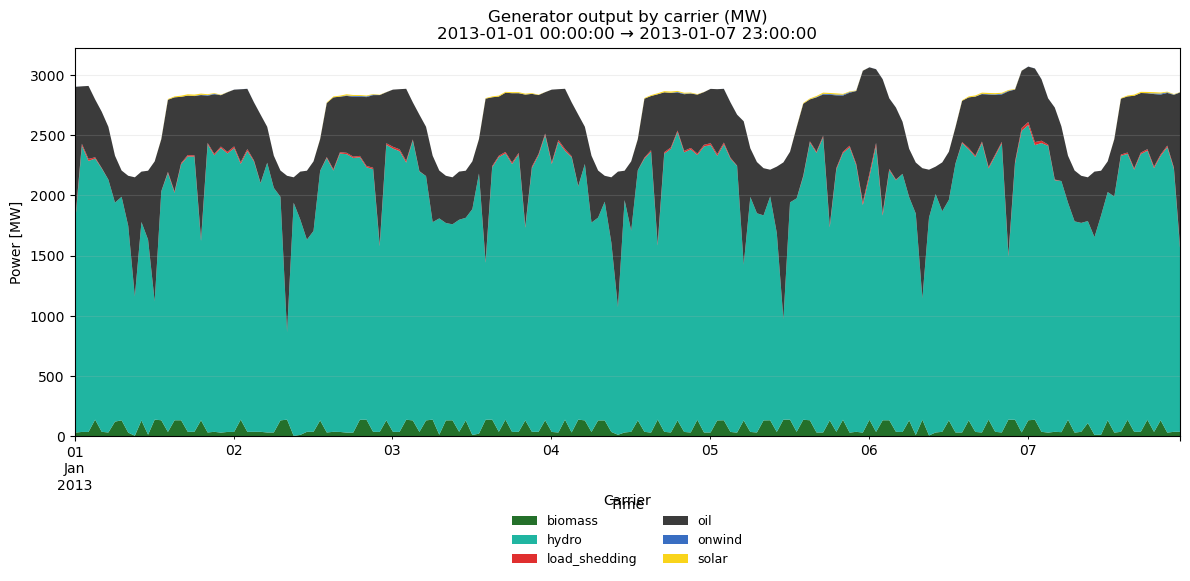

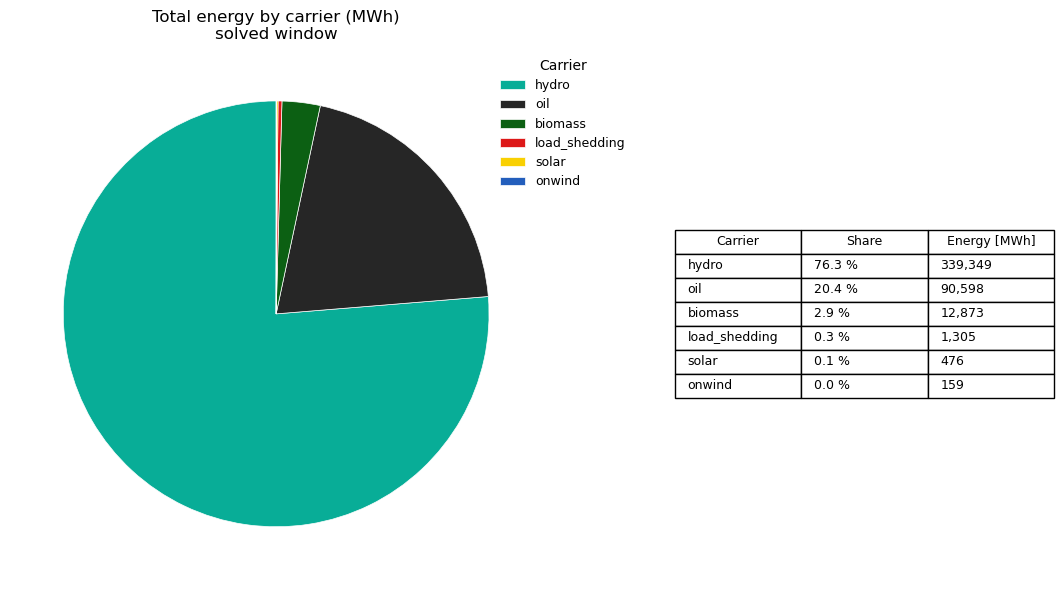

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n = network  # alias

def solved_snapshots(n, prefer=None):
    """Return the snapshots that actually have results."""
    if prefer is not None:
        return pd.Index(prefer)
    p = n.generators_t.p
    return p.index[p.notna().any(axis=1)]

# 1) pick the range to plot
try:
    # if you defined snapshots_subset earlier, use it
    plot_snaps = solved_snapshots(n, prefer=snapshots_subset)
except NameError:
    plot_snaps = solved_snapshots(n)

# 2) slice to existing data only
p = n.generators_t.p.loc[plot_snaps]                 # MW
gen_to_carrier = n.generators["carrier"].astype(str)
gen_to_carrier = gen_to_carrier.reindex(p.columns)   # align

# 3) aggregate by carrier
p_by_carrier = p.groupby(gen_to_carrier, axis=1).sum().sort_index()

# ---- hours weighting for energy ---------------------------------------------
def snapshot_hours(n, idx):
    """
    Return a Series with the duration [h] of each snapshot in idx.
    Uses n.snapshot_weightings if available, otherwise infers from dt.
    """
    sw = getattr(n, "snapshot_weightings", None)
    if sw is not None:
        if hasattr(sw, "columns") and "generators" in sw.columns:
            return sw.loc[idx, "generators"].astype(float)
        if isinstance(sw, pd.Series):
            return sw.loc[idx].astype(float)

    # fallback: infer from datetime index
    if len(idx) >= 2:
        dt = idx.to_series().diff().dt.total_seconds().shift(-1) / 3600.0
        dt.iloc[-1] = dt.iloc[-2] if len(dt) > 1 else 1.0
        return dt

    return pd.Series(1.0, index=idx)

hours = snapshot_hours(n, p_by_carrier.index)
energy_by_carrier = (p_by_carrier.mul(hours, axis=0)).sum(axis=0)

# sort descending for reporting
energy_by_carrier = energy_by_carrier.sort_values(ascending=False)

# ---- optional: colors from carriers table -----------------------------------
carrier_colors = {}
try:
    if hasattr(n, "carriers") and "color" in n.carriers.columns:
        carrier_colors = n.carriers["color"].dropna().astype(str).to_dict()
except Exception:
    pass
cols = [carrier_colors.get(c, None) for c in p_by_carrier.columns]

# =============================================================================
# 4) STACKED AREA: power by carrier over time
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
p_by_carrier.plot.area(
    ax=ax,
    linewidth=0,
    alpha=0.9,
    color=cols,
)

ax.set_title(
    f"Generator output by carrier (MW)\n"
    f"{plot_snaps[0]} → {plot_snaps[-1]}"
)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.2, axis="y")

# legend outside for clarity
ax.legend(
    title="Carrier",
    ncol=2,
    fontsize=9,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
)
fig.tight_layout()
plt.show()

# =============================================================================
# 5) PIE + TABLE: total energy by carrier (MWh) – publication style
# =============================================================================

# --- (a) optionally group very small slices into "other" ---------------------
total_energy = energy_by_carrier.sum()
threshold_fraction = 0.00000000002  # 2% – tweak if you want

small = energy_by_carrier[energy_by_carrier / total_energy < threshold_fraction]
big   = energy_by_carrier[energy_by_carrier / total_energy >= threshold_fraction]

if not small.empty:
    big["other"] = small.sum()

energy_for_plot = big.sort_values(ascending=False)
shares_pct = 100 * energy_for_plot / energy_for_plot.sum()

# colors (recomputed for possibly grouped series)
colors_pie = [carrier_colors.get(c, None) for c in energy_for_plot.index]

# --- (b) figure with two panels: pie + side table ---------------------------
fig, (ax_pie, ax_tab) = plt.subplots(
    1, 2,
    figsize=(11, 6),
    gridspec_kw={"width_ratios": [2.0, 1.3]}
)

# ----- left: clean pie (no text on wedges that can overlap) ------------------
wedges, _ = ax_pie.pie(
    energy_for_plot.values,
    labels=None,             # no labels on wedges → no overlap
    startangle=90,
    colors=colors_pie,
    wedgeprops=dict(linewidth=0.5, edgecolor="white"),
)

ax_pie.set_title("Total energy by carrier (MWh)\nsolved window")

# Use legend to map color → carrier
legend_labels = [
    f"{name}" for name in energy_for_plot.index
]
ax_pie.legend(
    wedges,
    legend_labels,
    title="Carrier",
    loc="upper left",
    bbox_to_anchor=(0.9, 1.0),
    frameon=False,
    fontsize=9,
)

# ----- right: small table with shares ---------------------------------------
ax_tab.axis("off")

table_data = [
    [name, f"{share:.1f} %", f"{val:,.0f}"]
    for name, share, val in zip(
        energy_for_plot.index,
        shares_pct.values,
        energy_for_plot.values,
    )
]

table = ax_tab.table(
    cellText=table_data,
    colLabels=["Carrier", "Share", "Energy [MWh]"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.25)  # a bit taller for readability

fig.tight_layout()
plt.show()


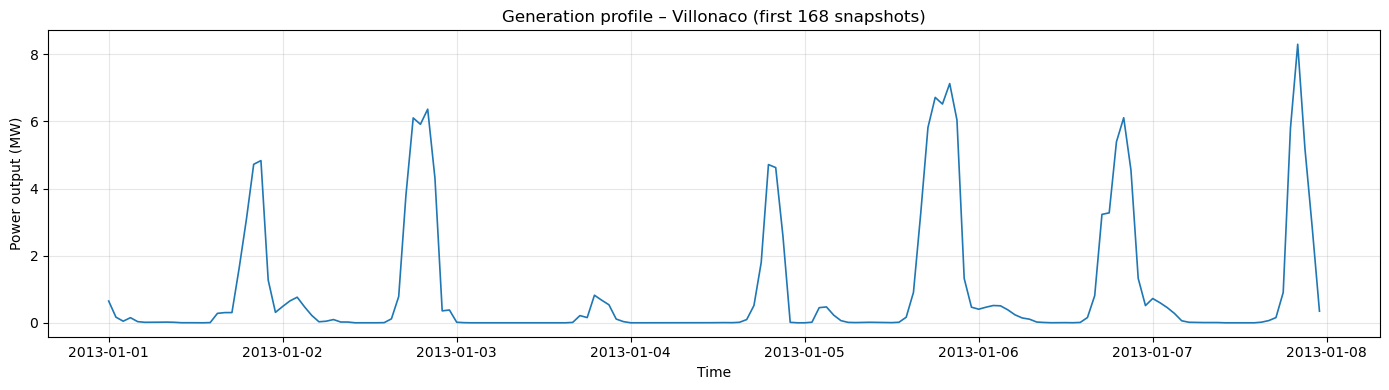

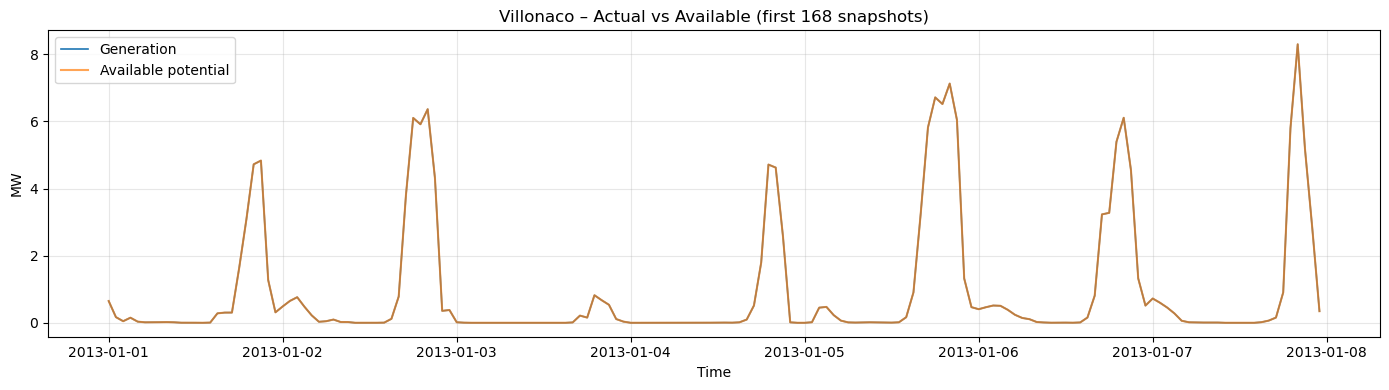

In [30]:
import matplotlib.pyplot as plt

gen_id = "Villonaco"

# define your restricted snapshot set
snaps = network.snapshots[:LEN_OPT]

# check generator / storage
if gen_id in network.generators.index:
    series = network.generators_t.p.loc[snaps, gen_id]
elif gen_id in network.storage_units.index:
    series = network.storage_units_t.p.loc[snaps, gen_id]
else:
    raise ValueError(f"Generator/storage '{gen_id}' not found in this network.")

# plot
plt.figure(figsize=(14,4))
plt.plot(series.index, series.values, linewidth=1.2)
plt.title(f"Generation profile – {gen_id} (first {LEN_OPT} snapshots)")
plt.xlabel("Time")
plt.ylabel("Power output (MW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# get p_nom or p_nom_opt
p_nom = network.generators.at[gen_id, "p_nom_opt"] \
        if "p_nom_opt" in network.generators.columns else \
        network.generators.at[gen_id, "p_nom"]

p_max = network.generators_t.p_max_pu.loc[snaps, gen_id] * p_nom

plt.figure(figsize=(14,4))
plt.plot(series, label="Generation", linewidth=1.2)
plt.plot(p_max, label="Available potential", alpha=0.7)
plt.title(f"{gen_id} – Actual vs Available (first {LEN_OPT} snapshots)")
plt.xlabel("Time")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


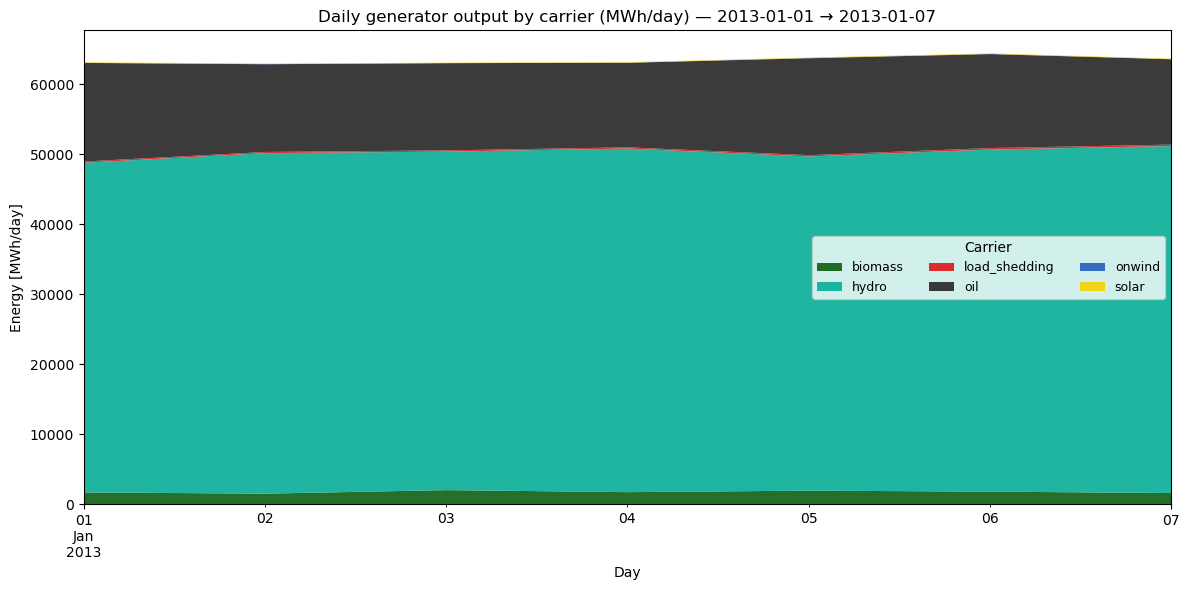

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n = network  # alias

def solved_snapshots(n, prefer=None):
    """Return the snapshots that actually have results."""
    if prefer is not None:
        return pd.Index(prefer)
    p = n.generators_t.p
    return p.index[p.notna().any(axis=1)]

# 1) pick the range to plot
try:
    plot_snaps = solved_snapshots(n, prefer=snapshots_subset)
except NameError:
    plot_snaps = solved_snapshots(n)

# 2) slice to existing data only
p = n.generators_t.p.loc[plot_snaps]                 # MW
gen_to_carrier = n.generators["carrier"].astype(str)
gen_to_carrier = gen_to_carrier.reindex(p.columns)   # align

# 3) aggregate by carrier (hourly)
p_by_carrier = p.groupby(gen_to_carrier, axis=1).sum().sort_index()

# ================================
# NEW PART → resample to daily sum
# ================================
# Ensure datetime index
p_by_carrier.index = pd.to_datetime(p_by_carrier.index)

# Daily sums in MWh/day
p_daily = p_by_carrier.resample("D").sum()
# ================================

# colors from carriers table
carrier_colors = {}
try:
    if hasattr(n, "carriers") and "color" in n.carriers.columns:
        carrier_colors = n.carriers["color"].dropna().astype(str).to_dict()
except Exception:
    pass
cols = [carrier_colors.get(c, None) for c in p_by_carrier.columns]

# 4) plot daily time series (stacked area)
plt.figure(figsize=(12,6))
p_daily.plot.area(ax=plt.gca(), linewidth=0, alpha=0.9, color=cols)
plt.title(f"Daily generator output by carrier (MWh/day) — {p_daily.index[0].date()} → {p_daily.index[-1].date()}")
plt.xlabel("Day")
plt.ylabel("Energy [MWh/day]")
plt.legend(title="Carrier", ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


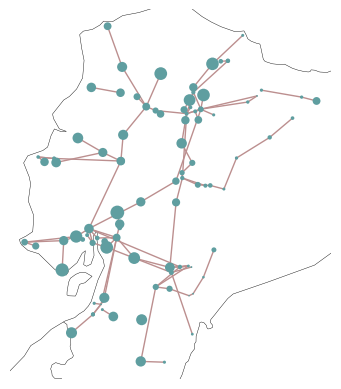

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1) Aggregate LOADS to DAILY SUMS
# ================================
# Convert snapshots to datetime (important)
network.loads_t.p.index = pd.to_datetime(network.loads_t.p.index)

# Daily sums per load_id (MWh/day)
load_daily = network.loads_t.p.resample("D").sum()     # shape: days × loads

# Total per load over all days
load_totals = load_daily.sum()                         # index: load_id


# ================================
# 2) Map load -> bus (ensure dtype consistent)
# ================================
bus_index_dtype = network.buses.index.dtype
load_to_bus = network.loads["bus"].astype(bus_index_dtype)


# ================================
# 3) Aggregate to BUS
# ================================
bus_sizes = load_totals.groupby(load_to_bus).sum()

# Include all buses, fill missing with 0
bus_sizes = bus_sizes.reindex(network.buses.index).fillna(0)

# Normalize and scale
bus_sizes = bus_sizes * 100 / max(bus_sizes)
bus_sizes = 1e-4 * bus_sizes      # scaling for plotting


# ================================
# 4) Plot network with daily-load sizes
# ================================
network.plot(bus_sizes=bus_sizes, line_widths=1)
plt.show()


In [33]:
network.generators_t.p

p_by_carrier.sum()

carrier
biomass           12872.552918
hydro            339349.248191
load_shedding      1304.821190
oil               90597.517427
onwind              159.377879
solar               475.946486
dtype: float64

In [34]:
# Total available capacity per carrier
p_nom_by_carrier = network.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
print("Installed capacity [MW]:")
print(p_nom_by_carrier)

# Compare installed capacity vs peak load
total_load = network.loads_t.p_set.sum(axis=1)
peak_load = total_load.max()
total_gen_cap = p_nom_by_carrier.sum()-p_nom_by_carrier["load_shedding"]

print(f"\nPeak load: {peak_load:.1f} MW")
print(f"Total installed generation capacity: {total_gen_cap:.1f} MW")

if total_gen_cap < peak_load:
    print("⚠️ Installed generation capacity < peak load → insufficient generation possible.")
else:
    print("✅ Installed generation capacity ≥ peak load → generation may be sufficient.")


Installed capacity [MW]:
carrier
load_shedding    1110000.00
hydro               5035.15
oil                 1958.72
biomass              142.90
solar                 23.60
onwind                16.50
Name: p_nom, dtype: float64

Peak load: 3104.6 MW
Total installed generation capacity: 7176.9 MW
✅ Installed generation capacity ≥ peak load → generation may be sufficient.


In [35]:
# Lines with heavy loading (potential congestion)
loading = abs(network.lines_t.p0 / network.lines.s_nom)
congested_lines = loading.max(axis=0)[loading.max(axis=0) > 0.9]
print(f"⚙️  Congested lines (>{90}% loading): {len(congested_lines)}")
display(congested_lines.sort_values(ascending=False))

# Transformers
if len(network.transformers):
    loading_tr = abs(network.transformers_t.p0 / network.transformers.s_nom)
    congested_tr = loading_tr.max(axis=0)[loading_tr.max(axis=0) > 0.9]
    print(f"⚙️  Congested transformers: {len(congested_tr)}")
    display(congested_tr.sort_values(ascending=False))




⚙️  Congested lines (>90% loading): 0


Series([], dtype: float64)

⚙️  Congested transformers: 0


Series([], dtype: float64)

In [36]:
# Identify buses with load_shedding generators
ls_gens = network.generators.query("carrier == 'load_shedding'")
ls_buses = ls_gens["bus"].unique()

# Total load_shedding per bus
load_shedding_by_bus = network.generators_t.p[ls_gens.index].sum()
load_shedding_by_bus = load_shedding_by_bus.groupby(ls_gens.loc[load_shedding_by_bus.index, "bus"]).sum()
load_shedding_by_bus=load_shedding_by_bus[load_shedding_by_bus>0]
load_shedding_by_bus.sort_values(ascending=False).to_csv("load_shedding_buses.csv")
# Print top affected buses
print("Top buses with load shedding:")
print(load_shedding_by_bus.sort_values(ascending=False).head(10).index)



Top buses with load shedding:
Index(['181', '64'], dtype='object', name='bus')


In [37]:
import pandas as pd
import numpy as np
import networkx as nx

n = network  # alias

# --- 0) (Optional) load your explicit list of LS buses ---
ls_bus_list = load_shedding_by_bus
try:
    df_ls = pd.read_csv("load_shedding_buses.csv")
    # assume a column named 'bus' (adapt if needed)
    col = "bus" if "bus" in df_ls.columns else df_ls.columns[0]
    ls_bus_list = df_ls[col].astype(str).unique().tolist()
except Exception:
    pass  # we'll derive from the network below if not provided

# --- 1) Build a bus graph with only usable branches ---
def build_bus_graph(n: "pypsa.Network", include_links=True):
    G = nx.Graph()

    # Add all buses as nodes
    for b in n.buses.index.astype(str):
        G.add_node(b)

    # Lines (only those with positive rating)
    if len(n.lines):
        lines_ok = n.lines[(n.lines.s_nom > 0) & (~n.lines.bus0.isna()) & (~n.lines.bus1.isna())]
        for name, row in lines_ok.iterrows():
            G.add_edge(str(row.bus0), str(row.bus1), kind="line", name=name, s_nom=row.s_nom)

    # Transformers
    if len(n.transformers):
        tr_ok = n.transformers[(n.transformers.s_nom > 0) & (~n.transformers.bus0.isna()) & (~n.transformers.bus1.isna())]
        for name, row in tr_ok.iterrows():
            G.add_edge(str(row.bus0), str(row.bus1), kind="trafo", name=name, s_nom=row.s_nom)

    # Links (HVDC, etc.) if desired
    if include_links and len(n.links):
        lk_ok = n.links[(n.links.p_nom > 0) & (~n.links.bus0.isna()) & (~n.links.bus1.isna())]
        for name, row in lk_ok.iterrows():
            G.add_edge(str(row.bus0), str(row.bus1), kind="link", name=name, p_nom=row.p_nom)
    return G

G = build_bus_graph(n)

# --- 2) Identify buses with real generators (exclude load_shedding) ---
gens = n.generators.copy()
gens["bus"] = gens["bus"].astype(str)
real_gens = gens[(gens["carrier"] != "load_shedding") & (gens["p_nom"] > 0)]
gen_buses = real_gens["bus"].unique().tolist()
gen_cap_by_bus = real_gens.groupby("bus")["p_nom"].sum()

# --- 3) Get the list of load-shedding buses ---
if ls_bus_list is None:
    # derive from generators_t: find LS generators actually used or present
    ls_gens = gens[gens["carrier"] == "load_shedding"].index
    # If you want only buses with *nonzero* LS dispatch, uncomment next line:
    used = n.generators_t.p[ls_gens].sum(axis=0); ls_gens = used[used>0].index
    ls_bus_list = gens.loc[ls_gens, "bus"].astype(str).unique().tolist()

# --- 4) Component-based reachability test ---
# Precompute connected components
comp_id = {}
for i, comp in enumerate(nx.connected_components(G)):
    for b in comp:
        comp_id[b] = i

# For each component, compute number of gen buses and total gen capacity
comp_stats = {}
for b, cid in comp_id.items():
    comp_stats.setdefault(cid, {"gen_buses": set(), "gen_cap": 0.0})
for b, cap in gen_cap_by_bus.items():
    cid = comp_id.get(b)
    if cid is not None:
        comp_stats[cid]["gen_buses"].add(b)
        comp_stats[cid]["gen_cap"] += float(cap)

# Build result table for LS buses
rows = []
for b in ls_bus_list:
    cid = comp_id.get(str(b), None)
    if cid is None:
        rows.append({"bus": str(b), "component": np.nan, "reachable_real_gen": False,
                     "gens_in_component": 0, "gen_cap_in_component_MW": 0.0})
        continue
    gens_in_comp = len(comp_stats[cid]["gen_buses"])
    cap_in_comp  = comp_stats[cid]["gen_cap"]
    reachable = gens_in_comp > 0 and cap_in_comp > 0
    rows.append({"bus": str(b), "component": cid, "reachable_real_gen": reachable,
                 "gens_in_component": gens_in_comp, "gen_cap_in_component_MW": cap_in_comp})

ls_reach = pd.DataFrame(rows).sort_values(["reachable_real_gen","gen_cap_in_component_MW"], ascending=[True, False])
print("Load-shedding buses connectivity summary:")
display(ls_reach.head(20))

# Save for audit if you like
ls_reach.to_csv("load_shedding_buses_connectivity.csv", index=False)


Load-shedding buses connectivity summary:


,bus,component,reachable_real_gen,gens_in_component,gen_cap_in_component_MW
0,181,0,True,29,6058.54
1,64,0,True,29,6058.54


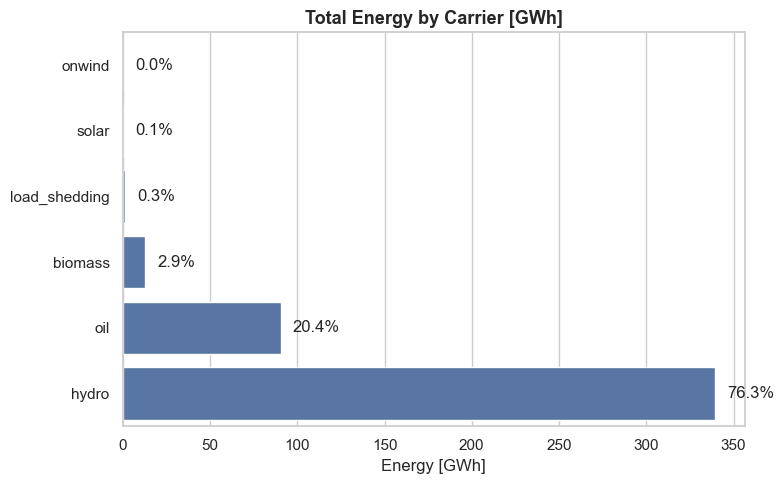

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Compute totals by carrier ---
p_by_carrier = network.generators_t.p.groupby(network.generators["carrier"], axis=1).sum()
total_by_carrier = p_by_carrier.sum() / 1e3  # GWh
total_sum = total_by_carrier.sum()

# --- Prepare sorted dataframe for seaborn ---
df_plot = (
    total_by_carrier.reset_index()
    .rename(columns={"index": "carrier", 0: "energy_gwh"})
)
df_plot.columns = ["carrier", "energy_gwh"]
df_plot["percentage"] = 100 * df_plot["energy_gwh"] / total_sum
df_sorted = df_plot.sort_values("energy_gwh", ascending=True)

# --- Plot with explicit order ---
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
ax = sns.barplot(
    data=df_sorted,
    y="carrier",
    x="energy_gwh",
    order=df_sorted["carrier"].tolist(),  # ensure order
)

# --- Annotations aligned with bars (iterate bars in plotted order) ---
xmax = df_sorted["energy_gwh"].max()
for bar, (_, row) in zip(ax.patches, df_sorted.iterrows()):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        x + 0.02 * xmax,  # small offset from bar end
        y,
        f"{row['percentage']:.1f}%",
        va="center",
        ha="left",
        clip_on=False,
    )

# --- Labels and layout ---
ax.set_title("Total Energy by Carrier [GWh]", fontsize=13, weight="bold")
ax.set_xlabel("Energy [GWh]")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [39]:
df_sorted

,carrier,energy_gwh,percentage
4,onwind,0.159378,0.035835
5,solar,0.475946,0.107012
2,load_shedding,1.304821,0.293377
0,biomass,12.872553,2.894273
3,oil,90.597517,20.370003
1,hydro,339.349248,76.299500


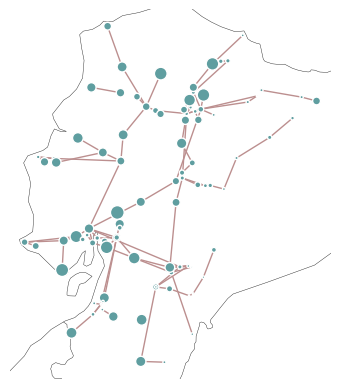

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Build bus_sizes from loads (sum over time), with index dtype aligned ---
# 1) totals per LOAD
load_totals = network.loads_t.p.sum()                  # index: load_id

# 2) map load -> bus, making sure dtype matches network.buses.index
bus_index_dtype = network.buses.index.dtype
load_to_bus = network.loads["bus"].astype(bus_index_dtype)

# 3) aggregate to BUS and reindex to full bus list
bus_sizes = load_totals.groupby(load_to_bus).sum()
bus_sizes = bus_sizes.reindex(network.buses.index).fillna(0)
bus_sizes = bus_sizes*100/max(bus_sizes)
# 4) scale for plotting
bus_sizes = 1e-4* bus_sizes

# (optional) sanity check
# print("bus_sizes dtype:", bus_sizes.index.dtype, "| buses dtype:", network.buses.index.dtype)

# --- Plot ---
network.plot(bus_sizes=bus_sizes, line_widths=1)
plt.show()


In [41]:
import pandas as pd
import numpy as np
import pandas as pd

# Time-series flows (snapshots x lines)
p0 = network.lines_t.p0  # MW

# Continuous ratings per line (Series indexed by line)
s_nom = network.lines["s_nom"]  # MVA (PyPSA convention); assume MW≈MVA if PF≈1

# Avoid division by zero/NaN
s_nom_safe = s_nom.replace({0: np.nan})

# Max loading over time per line (fraction of rating)
line_loading_max = p0.abs().div(s_nom_safe, axis=1).max(axis=0)

# Optional: as percent
line_loading_max_ = 100 * line_loading_max
line_loading_max.to_csv("line_loading.csv")

In [42]:
import pandas as pd
import numpy as np

# --- Transformer loading analysis ---

# Time-series flows (snapshots × transformers)
p0_trafo = network.transformers_t.p0  # MW

# Continuous ratings per transformer (MVA, indexed by transformer)
s_nom_trafo = network.transformers["s_nom"]

# Avoid division by zero / NaN
s_nom_trafo_safe = s_nom_trafo.replace({0: np.nan})

# Max loading over time per transformer (fraction of nominal rating)
trafo_loading_max = p0_trafo.abs().div(s_nom_trafo_safe, axis=1).max(axis=0)

# Optional: convert to percent
trafo_loading_max_pct = 100 * trafo_loading_max

# Save to CSV
trafo_loading_max_pct.to_csv("trafo_loading.csv")

# Print top-loaded transformers
print(trafo_loading_max_pct.sort_values(ascending=False).head(10).round(1))


Transformer
transf_45_1    51.0
transf_10_2    29.4
transf_10_1    14.7
transf_49_1    14.7
transf_45_0    11.7
transf_2_0      9.8
transf_7_1      9.0
transf_3_1      8.2
transf_42_0     7.2
transf_9_1      6.3
dtype: float64


In [43]:

# Add to lines DataFrame for reference
network.lines["max_loading"] = line_loading_max

# Get top 5
top5 = network.lines.sort_values("max_loading", ascending=False).head(5)

# Display concise table
cols = ["bus0", "bus1", "max_loading", "length", "v_nom"]
print("Top 5 most loaded lines:")
display(top5[cols])
for i, row in top5.iterrows():
    print(f"{i}: {row.bus0} ↔ {row.bus1} | loading={row.max_loading:.2f} p.u. | length={row.length:.1f} km")


Top 5 most loaded lines:


,bus0,bus1,max_loading,length,v_nom
Line,,,,,
14,11,14,0.7,7.669818,138.0
137,181,102,0.7,24.501073,138.0
3,111,7,0.7,8.552634,138.0
90,64,277,0.7,22.914154,138.0
84,38,273,0.7,9.036811,138.0


14: 11 ↔ 14 | loading=0.70 p.u. | length=7.7 km
137: 181 ↔ 102 | loading=0.70 p.u. | length=24.5 km
3: 111 ↔ 7 | loading=0.70 p.u. | length=8.6 km
90: 64 ↔ 277 | loading=0.70 p.u. | length=22.9 km
84: 38 ↔ 273 | loading=0.70 p.u. | length=9.0 km


In [44]:
network.lines[["bus0", "bus1", "length", "v_nom", "carrier"]].to_csv("lines_meta.csv")

network.transformers[["bus0", "bus1"]].to_csv("trafos_meta.csv")
network.buses[["v_nom", "lon", "lat"]].to_csv("buses_meta.csv")

In [45]:
import pandas as pd

# Load data
lines = pd.read_csv("line_loading.csv", index_col=0)
lines_meta = pd.read_csv("lines_meta.csv", index_col=0)
trafos = pd.read_csv("trafo_loading.csv", index_col=0)
trafos_meta = pd.read_csv("trafos_meta.csv", index_col=0)
buses = pd.read_csv("buses_meta.csv", index_col=0)

# Merge metadata
lines_full = lines_meta.join(lines, how="left")
trafos_full = trafos_meta.join(trafos, how="left")

# Rename columns
lines_full.columns = [c if c != lines_full.columns[-1] else "max_loading_pct"
                      for c in lines_full.columns]
trafos_full.columns = [c if c != trafos_full.columns[-1] else "max_loading_pct"
                       for c in trafos_full.columns]
print("=== Line Loading Summary ===")
print(lines_full["max_loading_pct"].describe())

print("\n=== Transformer Loading Summary ===")
print(trafos_full["max_loading_pct"].describe())

# Congestion ratio
n_lines = len(lines_full)
n_trafos = len(trafos_full)
high_lines = (lines_full["max_loading_pct"] > 90).sum()
high_trafos = (trafos_full["max_loading_pct"] > 90).sum()

print(f"\nLines >90% loaded: {high_lines}/{n_lines} ({100*high_lines/n_lines:.1f}%)")
print(f"Transformers >90% loaded: {high_trafos}/{n_trafos} ({100*high_trafos/n_trafos:.1f}%)")
print("\n=== Top 10 Congested Lines ===")
print(lines_full.sort_values("max_loading_pct", ascending=False).head(10))

print("\n=== Top 10 Congested Transformers ===")
print(trafos_full.sort_values("max_loading_pct", ascending=False).head(10))
# Merge voltage info for bus0
lines_full = lines_full.join(
    buses[["v_nom", "lon", "lat"]].add_prefix("bus0_"),
    on="bus0"
)
lines_full = lines_full.join(
    buses[["v_nom", "lon", "lat"]].add_prefix("bus1_"),
    on="bus1"
)

# Average loading per voltage level
voltage_summary = lines_full.groupby("v_nom")["max_loading_pct"].mean()
print("\nAverage line loading per voltage level:\n", voltage_summary)


=== Line Loading Summary ===
count    109.000000
mean       0.292943
std        0.212664
min        0.002036
25%        0.105210
50%        0.267321
75%        0.462581
max        0.700000
Name: max_loading_pct, dtype: float64

=== Transformer Loading Summary ===
count    19.000000
mean      9.372648
std      12.390828
min       0.000000
25%       1.469941
50%       6.264282
75%      10.749251
max      51.040452
Name: max_loading_pct, dtype: float64

Lines >90% loaded: 0/109 (0.0%)
Transformers >90% loaded: 0/19 (0.0%)

=== Top 10 Congested Lines ===
      bus0  bus1     length  v_nom carrier  max_loading_pct
Line                                                       
14      11    14   7.669818  138.0      AC         0.700000
137    181   102  24.501073  138.0      AC         0.700000
3      111     7   8.552634  138.0      AC         0.700000
90      64   277  22.914154  138.0      AC         0.700000
84      38   273   9.036811  138.0      AC         0.700000
81     146    24  24.28

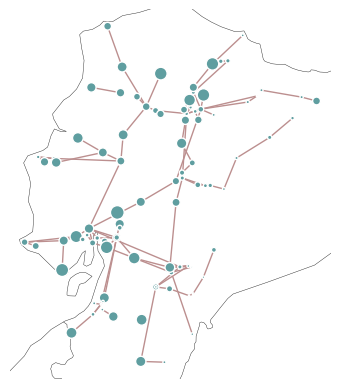

In [46]:
network.plot(bus_sizes=bus_sizes, line_widths=1)
plt.show()

In [47]:
lines_load = pd.read_csv("line_loading.csv", index_col=0)
lines_load*=100
lines_load

,0
Line,
0,12.809289
1,51.350778
2,25.495749
3,70.000000
4,40.069871
...,...
245,58.469592
246,46.258105
801,28.237084


Matched 109 / 109 lines; missing 0.


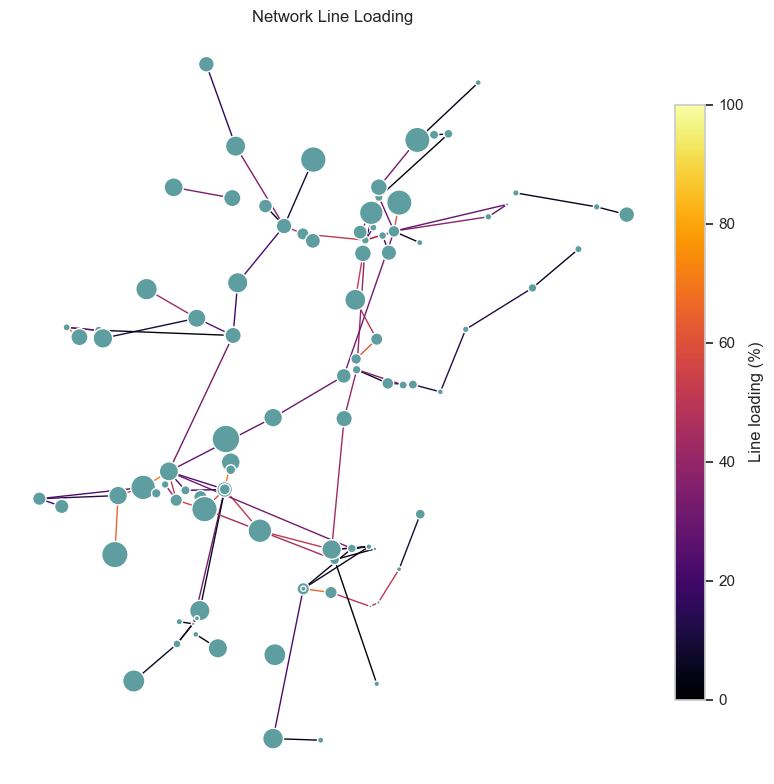

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load your line loading data (first column as Series) ---
lines_raw = pd.read_csv("line_loading.csv", index_col=0).iloc[:, 0].astype(float)  # e.g. 0..1
lines_raw *= 100.0  # -> %
# lines_raw = np.clip(lines_raw, 0, 150)

# --- Canonicalize indexes to strings on BOTH sides ---
def canon_idx(idx):
    return pd.Index(idx.astype(str).str.strip())

csv_idx = canon_idx(lines_raw.index)
net_idx = canon_idx(network.lines.index)

# Put canonical index on the data
lines_canon = lines_raw.copy()
lines_canon.index = csv_idx

# --- Align by label, keep the network’s order ---
aligned = lines_canon.reindex(net_idx)

# Diagnostics
matched = aligned.notna().sum()
missing = aligned.isna().sum()
print(f"Matched {matched} / {len(aligned)} lines; missing {missing}.")

# Optional: peek mismatches
if missing:
    csv_only = set(lines_canon.index) - set(net_idx)
    net_only = set(net_idx) - set(lines_canon.index)
    print("Examples only-in-CSV:", list(csv_only)[:5])
    print("Examples only-in-NET:", list(net_only)[:5])

# Fill missing with 0 (or choose another strategy)
aligned = aligned.fillna(0.0)

# --- Build a Series using the network’s ORIGINAL index (not canonical) ---
line_colors = pd.Series(aligned.values, index=network.lines.index)

# --- Plot ---
cmap = "inferno"
norm = plt.Normalize(vmin=0, vmax=100)

fig, ax = plt.subplots(figsize=(10, 8))
network.plot(
    ax=ax,
    geomap=False,
    bus_sizes=bus_sizes,
    line_colors=line_colors,   # <- index matches network.lines.index
    line_cmap=cmap,
    line_norm=norm,
    line_widths=1,
)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02).set_label("Line loading (%)")
plt.title("Network Line Loading")
plt.tight_layout()
plt.show()


In [49]:
import pandas as pd
import numpy as np

n = network  # just a shorthand

# 1) Identify load shedding generators
ls_gen = n.generators[n.generators.carrier == "load_shedding"].copy()
ls_gen_indices = ls_gen.index

# 2) Time series of load shedding (MW)
ls_p = n.generators_t.p[ls_gen_indices]   # snapshots x LS generators

# 3) Total LS per snapshot (MW)
ls_total = ls_p.sum(axis=1)

# 4) Hours where LS is actually > 0
threshold = 1e-3  # MW
ls_hours = ls_total[ls_total > threshold].index
print(f"Hours with load shedding: {len(ls_hours)}")


Hours with load shedding: 105


In [50]:
network.lines.to_csv("network_lines.csv")